# Выпускной проект Яндекс.Практикум (Data Scienсe)

**Описание проекта "Телеком":**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. 

**Задача проекта** — обучить модель для прогноза оттока клиентов.

**Описание услуг**

Оператор предоставляет два основных типа услуг:

* Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
* Интернет. Подключение бывает двух типов: через телефонную линию DSL (англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (англ. fiber optic).

Также абонентам доступен ряд услуг:

* Интернет-безопасность: антивирус (Device Protection) и блокировка опасных сайтов (Online Security);
* Выделенная линия технической поддержки (Tech Support);
* Облачное хранилище файлов для резервного копирования данных (Online Backup);
* Стриминговое телевидение (Streaming TV) и каталог фильмов (Streaming Movies).

За услуги клиенты могут платить ежемесячно или раз в 1–2 года. Доступны различные способы расчёта и возможность получить электронный чек.

**Описание данных**

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

    contract — информация о договорах;
    personal — персональные данные клиентов;
    internet — информация об интернет-услугах;
    phone — информация об услугах телефонии.

Таблица contract

    customerID — ID абонента;
    BeginDate — дата начала действия договора;
    EndDate — дата окончания действия договора;
    Type — тип оплаты: раз в год-два или ежемесячно;
    PaperlessBilling — электронный расчётный лист;
    PaymentMethod — тип платежа;
    MonthlyCharges — расходы за месяц;
    TotalCharges — общие расходы абонента.

Таблица personal

    customerID — ID пользователя;
    gender — пол;
    SeniorCitizen — является ли абонент пенсионером;
    Partner — есть ли у абонента супруг или супруга;
    Dependents — есть ли у абонента дети.

Таблица internet

    customerID — ID пользователя;
    InternetService — тип подключения;
    OnlineSecurity — блокировка опасных сайтов;
    OnlineBackup — облачное хранилище файлов для резервного копирования данных;
    DeviceProtection — антивирус;
    TechSupport — выделенная линия технической поддержки;
    StreamingTV — стриминговое телевидение;
    StreamingMovies — каталог фильмов.

Таблица phone

    customerID — ID пользователя;
    MultipleLines — подключение телефона к нескольким линиям одновременно.

*Информация о договорах актуальна на 1 февраля 2020 г.*

## Загрузка данных

Объявим необходимые библиотеки, подключимся к базе данных в Sqlite. Далее проведём первичное исследование таблиц. По условию задачи необходимо задать константу `RANDOM_STATE`. Её значение будет равно дате начала нашей работы над проектом. Значит, наша константа будет равняться `170325`.

Проверка версий Python и основных библиотек:

In [1]:
'''
!pip cache purge

import subprocess

# Упорядоченный список для контроля зависимостей
packages = [
    # Базовые зависимости 
    "shap==0.46.0",
    "numba==0.58.1",
    "numpy==1.23.5",
    "scipy==1.11.4",
    "python-dateutil==2.8.2",
    "pytz==2023.3.post1",

    # Основные библиотеки
    "pandas==1.5.3",
    "matplotlib==3.7.3",
    "seaborn==0.12.2",

    # Машинное обучение
    "scikit-learn==1.6.1",
    "lightgbm==3.3.1",
    "shap==0.46.0",
    "phik==0.12.4",
    "statsmodels==0.14.4",

    # Глубокое обучение
    "numba==0.58.1",
    "torch==2.5.1+cpu",
    "torchmetrics==1.7.0",
    "torchvision",

    # Зависимости visions
    "multimethod",
    "tangled-up-in-unicode",

    # Pydantic
    "pydantic==1.8.2",

    # Базы данных и типы
    "sqlalchemy==2.0.40",
    "visions==0.7.5"
]

def install_packages():
    print("Установка пакетов...")

    # Установка всех пакетов одной командой для корректного разрешения зависимостей
    try:
        subprocess.check_call([
            "pip", "install",
            "--extra-index-url", "https://download.pytorch.org/whl/cpu"
        ] + packages)
        print("\nВсе пакеты успешно установлены!")
    except subprocess.CalledProcessError as e:
        print(f"\nОшибка установки: {e}")

    print("\nПроверка окружения:")
    subprocess.call(["pip", "check"])

if __name__ == "__main__":
    install_packages()
'''

'\n!pip cache purge\n\nimport subprocess\n\n# Упорядоченный список для контроля зависимостей\npackages = [\n    # Базовые зависимости \n    "shap==0.46.0",\n    "numba==0.58.1",\n    "numpy==1.23.5",\n    "scipy==1.11.4",\n    "python-dateutil==2.8.2",\n    "pytz==2023.3.post1",\n\n    # Основные библиотеки\n    "pandas==1.5.3",\n    "matplotlib==3.7.3",\n    "seaborn==0.12.2",\n\n    # Машинное обучение\n    "scikit-learn==1.6.1",\n    "lightgbm==3.3.1",\n    "shap==0.46.0",\n    "phik==0.12.4",\n    "statsmodels==0.14.4",\n\n    # Глубокое обучение\n    "numba==0.58.1",\n    "torch==2.5.1+cpu",\n    "torchmetrics==1.7.0",\n    "torchvision",\n\n    # Зависимости visions\n    "multimethod",\n    "tangled-up-in-unicode",\n\n    # Возможное решение конфликта pydantic (раскомментируйте, если необходимо)\n    "pydantic==1.8.2",\n\n    # Базы данных и типы\n    "sqlalchemy==2.0.40",\n    "visions==0.7.5"\n]\n\ndef install_packages():\n    print("Установка пакетов...")\n\n    # Установка вс

In [2]:
%load_ext watermark

import sys

try:
    import notebook
    jupyter_version = f"Jupyter Notebook: {notebook.__version__}"
except ImportError:
    jupyter_version = "Jupyter Notebook не установлен"

try:
    import jupyterlab
    jupyterlab_version = f"JupyterLab: {jupyterlab.__version__}"
except ImportError:
    jupyterlab_version = "JupyterLab не установлен"

%watermark -a "Samoilov V.R." -u -d -v -p numpy,pandas,matplotlib,sklearn,lightgbm,seaborn,shap,phik,torch,torchmetrics,numba,statsmodels,scipy,sqlalchemy,visions
print(jupyter_version)
print(jupyterlab_version)

Author: Samoilov V.R.

Last updated: 2025-04-05

Python implementation: CPython
Python version       : 3.9.5
IPython version      : 8.18.1

numpy       : 1.23.5
pandas      : 1.5.3
matplotlib  : 3.7.3
sklearn     : 1.6.1
lightgbm    : 3.3.1
seaborn     : 0.12.2
shap        : 0.46.0
phik        : 0.12.4
torch       : 2.5.1+cpu
torchmetrics: 1.7.0
numba       : 0.58.1
statsmodels : 0.14.4
scipy       : 1.11.4
sqlalchemy  : 2.0.40
visions     : 0.7.5

Jupyter Notebook: 6.4.0
JupyterLab не установлен


/opt/conda/lib/python3.9/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
/opt/conda/lib/python3.9/site-packages/visions/backends/shared/nan_handling.py:51: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def hasna(x: np.ndarray) -> bool:


In [3]:
# --- Для работы с файловой системой ---
import os
import webbrowser

# --- Работа с данными ---
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text, inspect

# --- Визуализация ---
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- Модели и метрики Scikit-learn ---
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, 
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, RocCurveDisplay, accuracy_score, 
    confusion_matrix, precision_score, recall_score, 
    precision_recall_curve
)

# --- CatBoost и Optuna ---
from catboost import CatBoostClassifier
import optuna

# --- SHAP ---
import shap

# --- Настройки ---
pd.set_option('display.max_columns', None)  # Отображать все столбцы
RANDOM_STATE = 170325  # Фиксированное значение для воспроизводимости результатов
%matplotlib inline

In [4]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU is available")
    print(torch.cuda.get_device_name(0)) # Выводит имя устройства GPU
else:
    print("GPU is not available")

# Конфигурация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

False
GPU is not available


In [5]:
# Подключение к базе данных

# Скачиваем базу данных - ссылка удалена
#if not os.path.exists('ds-plus-final.db'):
#    !wget https://XYZ

engine = create_engine('sqlite:///ds-plus-final.db')

# Улучшенная функция для загрузки данных
def load_sql_table(table_name: str) -> pd.DataFrame:
    """Безопасная загрузка таблицы с обработкой ошибок"""
    try:
        with engine.connect() as conn:
            query = text(f'SELECT * FROM {table_name}')
            return pd.read_sql(query, conn)
    except Exception as e:
        print(f"Ошибка при загрузке таблицы {table_name}: {e}")
        return pd.DataFrame()

# Функция вывода информации
def print_table_info(df: pd.DataFrame, table_name: str) -> None:
    """
    Выводит информацию о таблице с обработкой ошибок отображения
    """
    
    print(f"\n{'='*50}")
    print(f"Анализ таблицы: {table_name}")
    print(f"Всего записей: {len(df)}")
    
    try:
        print("\nПервые 5 строк:")
        display(df.head())  
    except Exception as e:
        print(f"Ошибка при отображении данных: {e}")
    
    try:
        print("\nИнформация о колонках:")
        print(df.info())
    except Exception as e:
        print(f"Ошибка при выводе информации: {e}")
    
    print("="*50)

# Проверяем доступные таблицы
inspector = inspect(engine)
available_tables = inspector.get_table_names()
print(f"Доступные таблицы: {available_tables}")

try:
    # Загрузка данных
    contract_df = load_sql_table('contract')
    personal_df = load_sql_table('personal')
    internet_df = load_sql_table('internet')
    phone_df = load_sql_table('phone')

    # Вывод информации
    print_table_info(contract_df, 'contract')
    print_table_info(personal_df, 'personal')
    print_table_info(internet_df, 'internet')
    print_table_info(phone_df, 'phone')

except Exception as e:
    print(f"Ошибка: {e}")
    raise

Доступные таблицы: ['contract', 'data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 'data_temp', 'data_wire', 'data_wire_time', 'internet', 'personal', 'phone']

Анализ таблицы: contract
Всего записей: 7043

Первые 5 строк:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6   MonthlyCharges    7043 non-null   object
 7   TotalCharges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB
None

Анализ таблицы: personal
Всего записей: 7043

Первые 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   object
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB
None

Анализ таблицы: internet
Всего записей: 5517

Первые 5 строк:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None

Анализ таблицы: phone
Всего записей: 6361

Первые 5 строк:


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None


### Промежуточный вывод:

Данные загружены, соответствуют описанию.

## Предобработка данных

Проведём необходимую предобработку данных.

Функции для предобработки и вывода графиков:

In [6]:
def analyze_dataframe(df, table_name="Dataframe"):
    """
    Анализирует DataFrame, выводя графики и статистику для числовых и категориальных столбцов.
    Для числовых столбцов строится гистограмма (или график временного ряда, если столбец с датами)
    и ящик с усами, если количество уникальных значений больше 10. Иначе строится countplot.
    Для категориальных столбцов строится круговая диаграмма (кроме столбца 'customer_id').

    Args:
        df (pd.DataFrame): DataFrame для анализа.
        table_name (str): Название таблицы для заголовков.
    """

    print(f"\n=== Анализ DataFrame: {table_name} ===")

    # Анализ временнЫх столбцов
    time_cols = df.select_dtypes(include=['datetime64']).columns
    print("\n=== Анализ временнЫх столбцов ===")
    for i, col in enumerate(time_cols):
        if df[col].nunique() > 10:  
            sns.histplot(x=df[col], kde=True, multiple='stack', bins=75, alpha=0.7)
            plt.show()
    
    # Анализ числовых столбцов
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
    print("\n=== Анализ числовых столбцов ===")
    for i, col in enumerate(numerical_cols):
        if col != 'id':  # Исключаем столбец 'id'
            if df[col].nunique() > 10:  # Если больше 10 уникальных значений
                fig, ax = plt.subplots(1, 2, figsize=(16, 4))
                display(round(df[col].agg(['count', 'mean', 'median', 'max', 'min']), 2).to_frame())
                sns.histplot(x=df[col], kde=True, multiple='stack', bins=50, ax=ax[0], alpha=0.7)
                sns.boxplot(x=df[col], ax=ax[1])

                ax[0].set_title(f"Гистограмма и график плотности распределения: {col}")
                ax[0].set_xlabel(col, fontsize=15)
                ax[0].set_ylabel("Frequency", fontsize=15)
                ax[0].grid(axis='y')
                ax[1].set_title(f"Ящик с усами: {col}")
                ax[1].set_xlabel(col, fontsize=15)
                plt.tight_layout()
                plt.show()
            else:  # Если меньше или равно 10 уникальных значений, считаем категориальным
                display(round(df[col].agg(['count', 'mean', 'median', 'max', 'min']), 2).to_frame())
                plt.figure(figsize=(8, 6))  # зададим размер графика
                sns.countplot(x=df[col])
                plt.grid(axis='y')
                plt.gca().set_axisbelow(True)
                plt.title(f"Распределение категорий в столбце {col}")
                plt.tight_layout()
                plt.show()


    # Анализ категориальных столбцов
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    print("\n=== Анализ категориальных столбцов ===")
    for col in categorical_cols:
        if col != 'customer_id':  # Исключаем столбец 'customer_id'
            plt.figure(figsize=(8, 6))  # Задаем размер графика
            plt.pie(x=df[col].value_counts(), labels=df[col].value_counts().index, autopct='%1.1f%%')
            plt.title(f"Диаграмма значений столбца {col}")
            plt.show()
        else:
            print(f"\nПропуск анализа столбца {col} (customer_id), так как он содержит уникальные идентификаторы.")

    print("\n=== Завершено ===")
    
def convert_end_date(date_str):
    """Конвертирует значение end_date в datetime.

    Аргументы:
        date_str (str): Строковое значение даты или 'No'

    Возвращает:
        datetime64[ns]: Дата либо 2020-02-01 для значений 'No'.
    """
    if date_str == 'No':
        return pd.to_datetime('2020-02-01')  # Возвращаем Timestamp
    try:
        return pd.to_datetime(date_str)  # Преобразуем в Timestamp
    except (ValueError, TypeError):
        return pd.NaT  # Возвращаем NaT для некорректных дат

def clean_currency(value):
    """Функция для очистки денежных значений"""
    if isinstance(value, str):
        # Удаляем все нечисловые символы кроме точки и минуса
        cleaned = ''.join(c for c in value if c.isdigit() or c in '.-')
        return float(cleaned) if cleaned else 0.0
    return float(value)

def mixed_to_binary(value) -> int:
    """Конвертирует смешанные форматы в бинарные 0/1"""
    if pd.isna(value):
        return 'unknown'

    str_value = str(value).strip().lower()
    true_values = {'yes', 'y', 'true', 't', '1', 'on'}
    return 1 if str_value in true_values else 0

Датафрейм `contract_df`:

* пропуски в данных отсутствуют;
* имена столбцов приведём к стандартному виду;
* столбцы `begin_date` и `end_date` приведём к временнОму формату, обрежем время. В строках, где значение `end_date`='No', поставим дату выгрузки датасета (1 февраля 2020 г.);
* столбцы `monthly_charges` и `total_charges` преобразуем в числовой формат;
* столбец `paperless_billing` преобразуем в значения 0/1;
* проверим датасет на дубликаты. Если они есть, удалим их.


Проверка дубликатов:
Всего строк: 7043
Уникальных customer_id: 7043
Дубликатов customer_id не найдено

Пропущенные значения:
customer_id          0
begin_date           0
end_date             0
type_pay             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
dtype: int64

Анализ таблицы: contract_df
Всего записей: 7043

Первые 5 строк:


,customer_id,begin_date,end_date,type_pay,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,2020-02-01,One year,0,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,1,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,2020-02-01,One year,0,Bank transfer (automatic),42.30,1960.60
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,1,Electronic check,70.70,353.50



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type_pay           7043 non-null   object        
 4   paperless_billing  7043 non-null   int64         
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 440.3+ KB
None

=== Анализ DataFrame: Распределение признаков ===

=== Анализ временнЫх столбцов ===


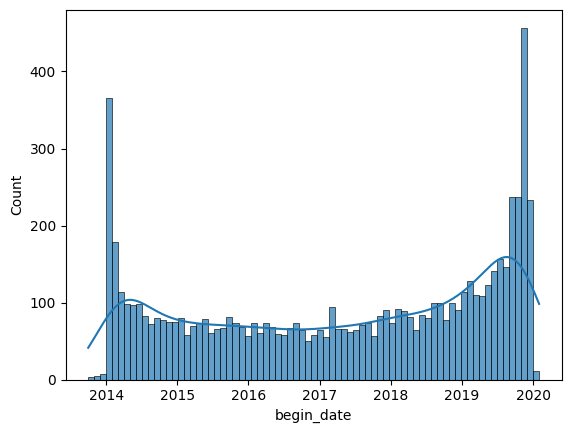

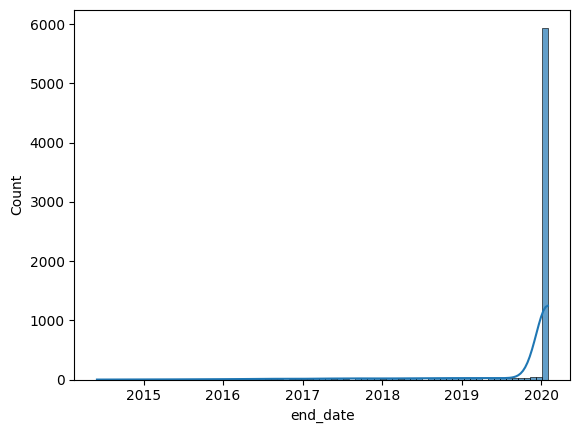


=== Анализ числовых столбцов ===


,paperless_billing
count,7043.00
mean,0.59
median,1.00
max,1.00
min,0.00


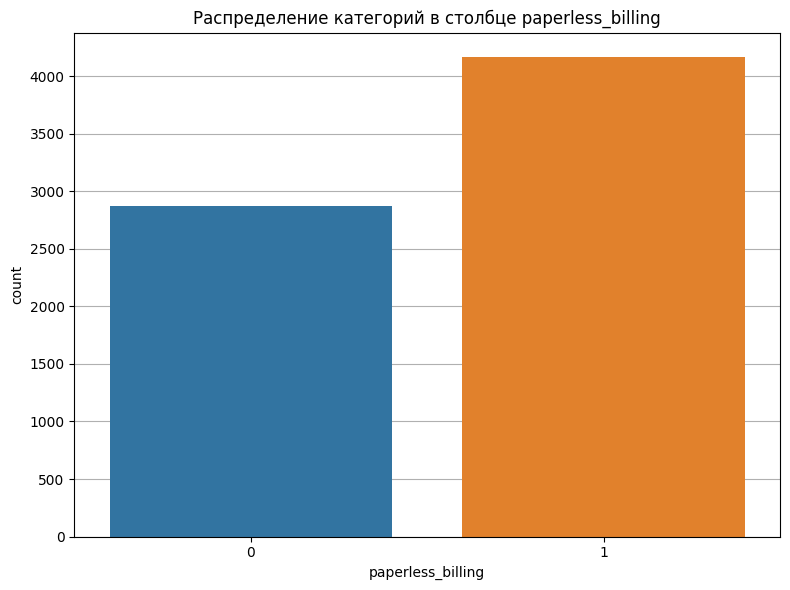

,monthly_charges
count,7043.00
mean,64.76
median,70.35
max,118.75
min,18.25


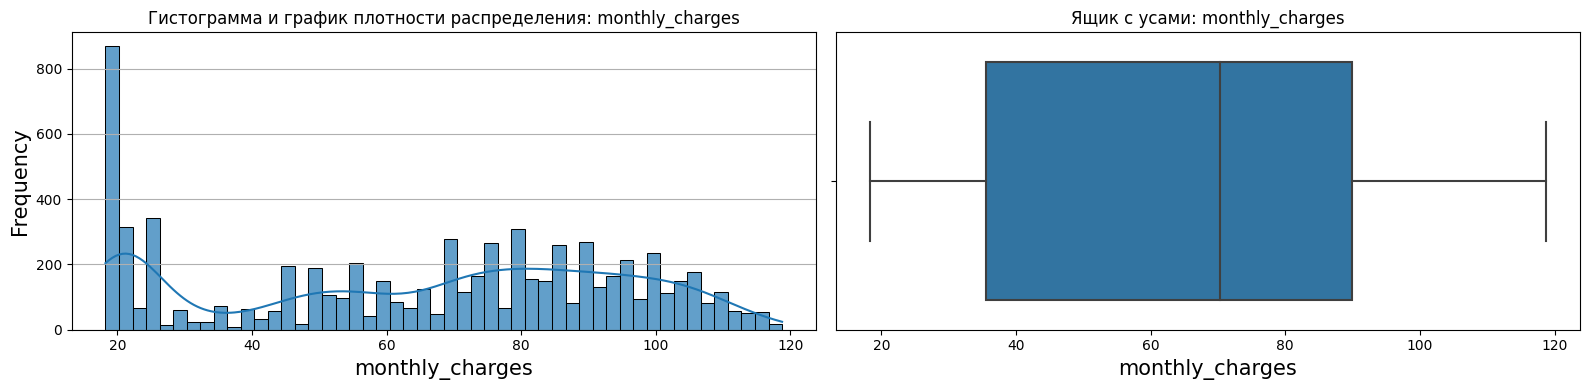

,total_charges
count,7043.00
mean,2115.31
median,1343.35
max,9221.38
min,0.00


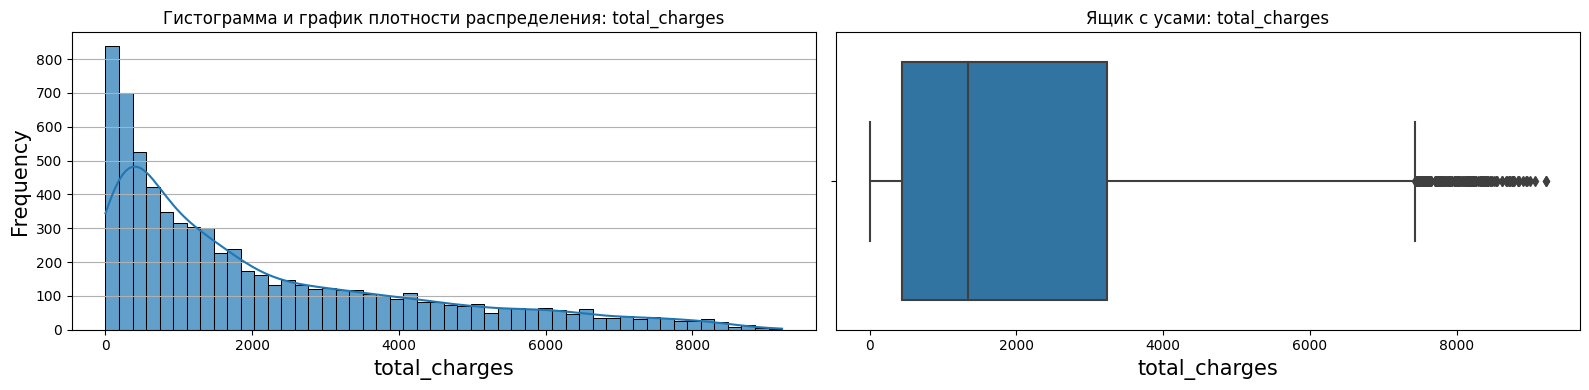


=== Анализ категориальных столбцов ===

Пропуск анализа столбца customer_id (customer_id), так как он содержит уникальные идентификаторы.


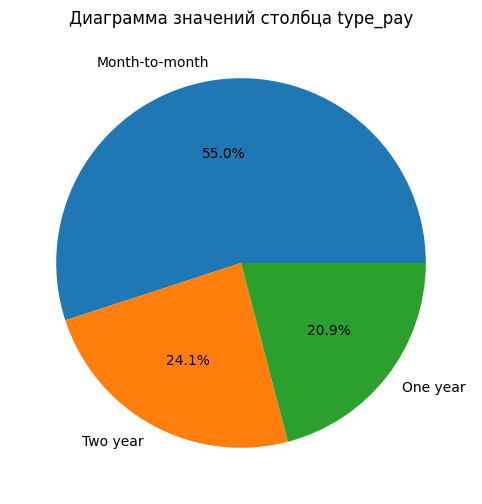

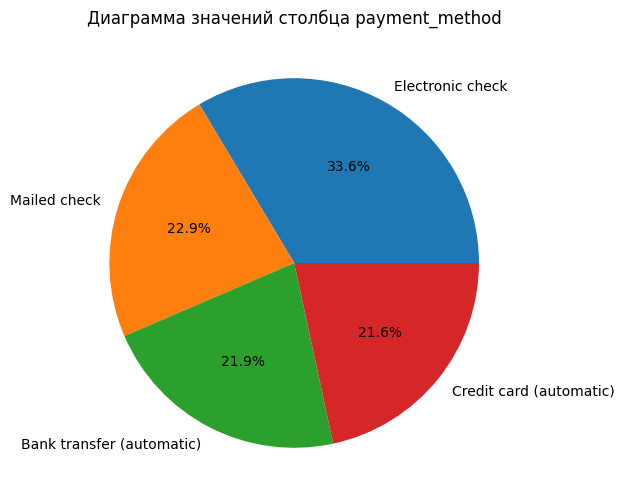


=== Завершено ===

Дополнительные проверки:
Минимальная дата начала: 2013-10-01 00:00:00
Максимальная дата окончания: 2020-02-01 00:00:00
Диапазон monthly_charges: 18.25 - 118.75


In [7]:
# Переименование столбцов
contract_df = contract_df.rename(columns={
    'customerID': 'customer_id',
    'BeginDate': 'begin_date',
    'EndDate': 'end_date',
    'Type': 'type_pay',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges'
})

# Преобразование begin_date в datetime и обрезка времени
contract_df['begin_date'] = pd.to_datetime(contract_df['begin_date'], errors='coerce')

# Применение функции преобразования
contract_df['end_date'] = contract_df['end_date'].apply(convert_end_date)

# Очистка денежных значений с проверкой
for money_col in ['monthly_charges', 'total_charges']:
    try:
        contract_df[money_col] = contract_df[money_col].apply(clean_currency)
        # Проверка на отрицательные значения
        if (contract_df[money_col] < 0).any():
            print(f"Внимание: в столбце {money_col} есть отрицательные значения")
    except Exception as e:
        print(f"Ошибка обработки столбца {money_col}: {e}")

# Проверка дубликатов
print("\nПроверка дубликатов:")
print(f"Всего строк: {len(contract_df)}")
print(f"Уникальных customer_id: {contract_df['customer_id'].nunique()}")

duplicates = contract_df.duplicated(subset=['customer_id'], keep=False)
if duplicates.any():
    print("\nНайдены дубликаты customer_id:")
    display(contract_df[duplicates].sort_values('customer_id').head())
else:
    print("Дубликатов customer_id не найдено")

# Преобразование paperless_billing
try:
    contract_df['paperless_billing'] = contract_df['paperless_billing'].apply(mixed_to_binary)
    # Проверка результата
    unique_values = contract_df['paperless_billing'].unique()
    if len(unique_values) > 2 or set(unique_values) - {0, 1}:
        print("Предупреждение: paperless_billing содержит не только 0 и 1")
except Exception as e:
    print(f"Ошибка преобразования paperless_billing: {e}")

# Проверка пропущенных значений
print("\nПропущенные значения:")
print(contract_df.isnull().sum())

# Вывод информации и анализ
print_table_info(contract_df, 'contract_df')
analyze_dataframe(contract_df, 'Распределение признаков')

# Дополнительные проверки
print("\nДополнительные проверки:")
print(f"Минимальная дата начала: {contract_df['begin_date'].min()}")
print(f"Максимальная дата окончания: {contract_df['end_date'].max()}")
print(f"Диапазон monthly_charges: {contract_df['monthly_charges'].min()} - {contract_df['monthly_charges'].max()}")

### Промежуточные выводы:

* `begin_date` - наблюдается бимодальное распределение значений. В начале графика пик объясняется высокой рекламной активностью на старте работы провайдера, интенсивным приростом новых клиентов на выгодных условиях. На протяжении следующих лет наблюдается стабилизация притока новых клиентов (примерно на уровне 70-80 клиентов в месяц). С начала 2018 г. начинается рост привлечения. Вероятно, это связано с запуском новых предложений и функций для клиентов, работой "сарафанного радио". 
* `end_date` - наблюдается пиковое значение в конечной дате 1 февраля 2020 г. Это связано с тем, что процент уходящих клиентов мал, большинство решило остаться у этого провайдера.
* `paperless_billing` - количество электронных квитанций больше примерно на треть.
* `monthly_charges` - наблюдается бимодальное распределение значений. Первый пик в районе 20 у.е. означает, что много клиентов используют минимальный пакет услуг (например, базовый тариф интернта или телефонно связи). Также этот пик смещает среднее значение относительно медианы. Второй пик наблюдается в районе 70-80 у.е. Скорее всего, это стоимость оптимального пакета услуг для остальной части клиентов. Выбросы по всему графику олицетворяют собой, вероятно, вариативность стоимости различных наборов услуг.
* `total_charges` - наблюдается односторонее распределение значений. Чем меньше сумма платежей за всё время, тем меньше таких клиентов, что логично.
* `type_pay` - больше половины клиентов платят ежемесячно. Почти четверть - используют двухгодичный тариф. Пятая часть - используют годовой тариф.
* `payment_method` - треть клиентов используют электронные платежи. Остальные виды оплат распределены равномерно. 

Датафрейм `personal_df`:

* пропуски в данных отсутствуют;
* имена столбцов приведём к стандартному виду
* столбцы `senior`, `partner`, `dependents` преобразуем в булевы значения;
* проверим датасет на дубликаты. Если они есть, удалим их.

Дубликаты по customer_id: 0

Дубликатов не обнаружено

Анализ таблицы: personal_df
Всего записей: 7043

Первые 5 строк:


,customer_id,gender,senior,partner,dependents
0,7590-VHVEG,Female,0,1,0
1,5575-GNVDE,Male,0,0,0
2,3668-QPYBK,Male,0,0,0
3,7795-CFOCW,Male,0,0,0
4,9237-HQITU,Female,0,0,0



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  7043 non-null   object
 1   gender       7043 non-null   object
 2   senior       7043 non-null   int64 
 3   partner      7043 non-null   int64 
 4   dependents   7043 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 275.2+ KB
None

=== Анализ DataFrame: Распределение признаков ===

=== Анализ временнЫх столбцов ===

=== Анализ числовых столбцов ===


,senior
count,7043.00
mean,0.16
median,0.00
max,1.00
min,0.00


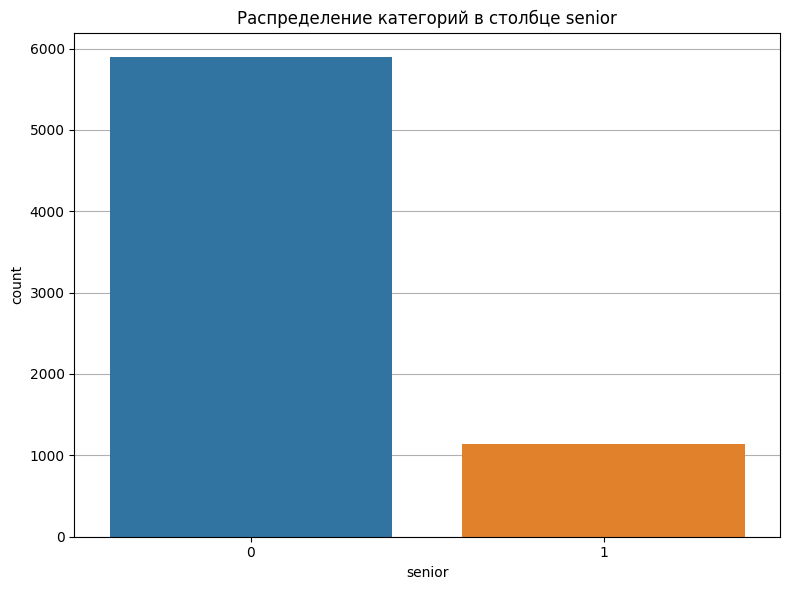

,partner
count,7043.00
mean,0.48
median,0.00
max,1.00
min,0.00


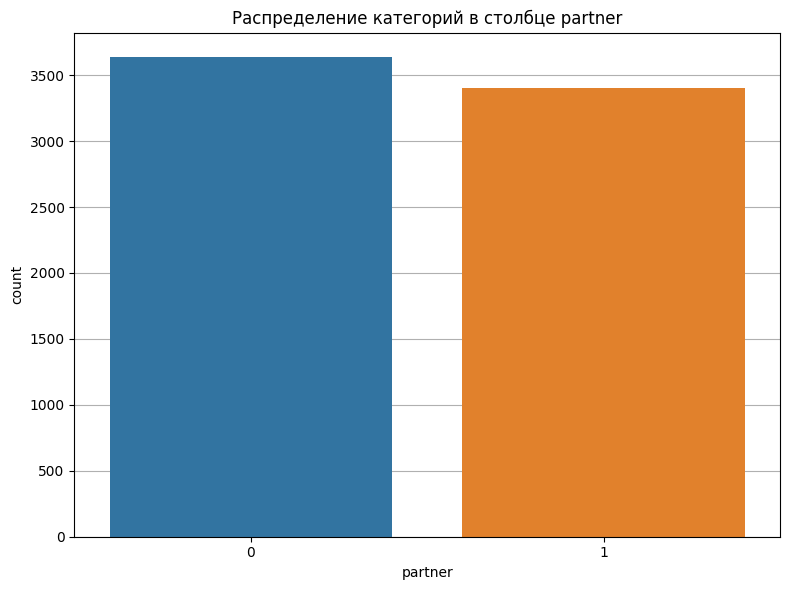

,dependents
count,7043.0
mean,0.3
median,0.0
max,1.0
min,0.0


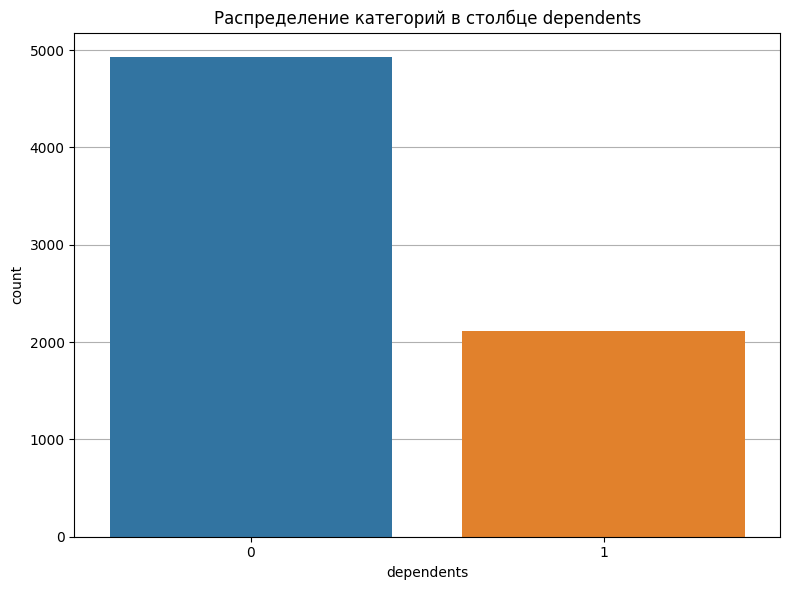


=== Анализ категориальных столбцов ===

Пропуск анализа столбца customer_id (customer_id), так как он содержит уникальные идентификаторы.


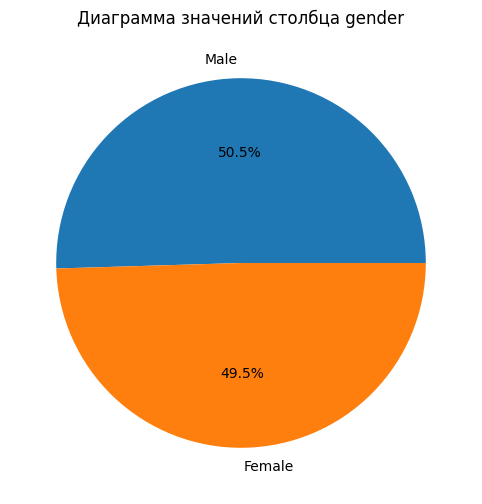


=== Завершено ===


In [8]:
# Переименование столбцов
personal_df.rename(
    columns={
        'customerID': 'customer_id', 
        'SeniorCitizen': 'senior', 
        'Partner': 'partner',
        'Dependents': 'dependents'
    }, 
    inplace=True
)

# Преобразование в 0/1
bool_cols = ['senior', 'partner', 'dependents']
for col in bool_cols:
    personal_df[col] = personal_df[col].map(mixed_to_binary)
    
# Проверка дубликатов по ключевому полю customer_id
print('Дубликаты по customer_id:', personal_df['customer_id'].duplicated().sum())

# Вывод самих дублированных строк (если есть)
if personal_df.duplicated().sum() > 0:
    print("\nПримеры дубликатов:")
    display(personal_df[personal_df.duplicated(keep=False)].sort_values('customer_id').head())
else:
    print("\nДубликатов не обнаружено")

# Вывод общей информации и графиков    
print_table_info(personal_df, 'personal_df')
analyze_dataframe(personal_df, 'Распределение признаков')

### Промежуточные выводы:

* `senior` - примерно пятая часть клиентов является пенсионерами. 
* `partner` - клиентов-холостяков и в браке примерно одинаковое количество.
* `dependents` - количество клиентов с иждивенцами составляет примерно половину от клиентов без них.
* `gender` - клиентов-мужчин и женщин примерно одинаковое количество.

Датафрейм `internet_df`:

* пропуски в данных отсутствуют;
* имена столбцов приведём к стандартному виду;
* столбцы `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies` преобразуем в булевы значения;
* проверим датасет на дубликаты. Если они есть, удалим их.

Дубликаты по customer_id: 0

Дубликатов не обнаружено

Анализ таблицы: phone_df
Всего записей: 5517

Первые 5 строк:


,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,0,1,0,0,0,0
1,5575-GNVDE,DSL,1,0,1,0,0,0
2,3668-QPYBK,DSL,1,1,0,0,0,0
3,7795-CFOCW,DSL,1,0,1,1,0,0
4,9237-HQITU,Fiber optic,0,0,0,0,0,0



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   int64 
 3   online_backup      5517 non-null   int64 
 4   device_protection  5517 non-null   int64 
 5   tech_support       5517 non-null   int64 
 6   streaming_tv       5517 non-null   int64 
 7   streaming_movies   5517 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 344.9+ KB
None

=== Анализ DataFrame: Распределение признаков ===

=== Анализ временнЫх столбцов ===

=== Анализ числовых столбцов ===


,online_security
count,5517.00
mean,0.37
median,0.00
max,1.00
min,0.00


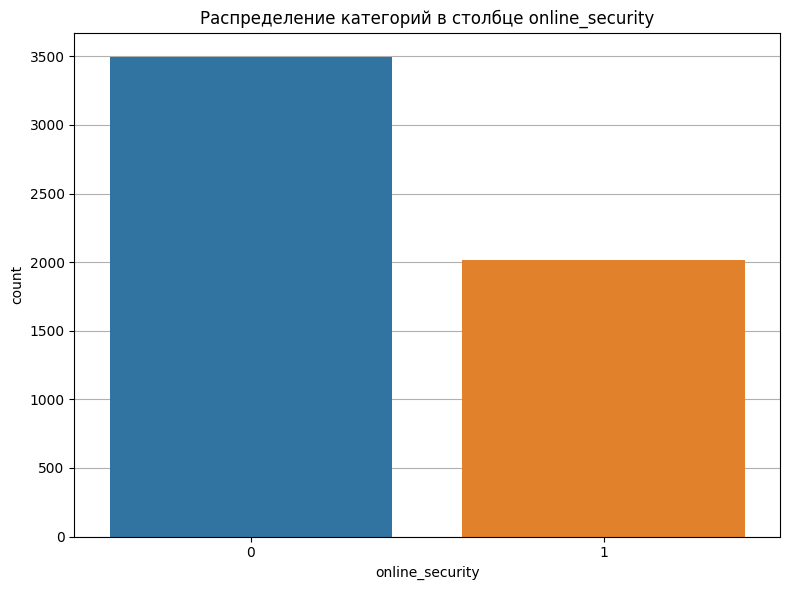

,online_backup
count,5517.00
mean,0.44
median,0.00
max,1.00
min,0.00


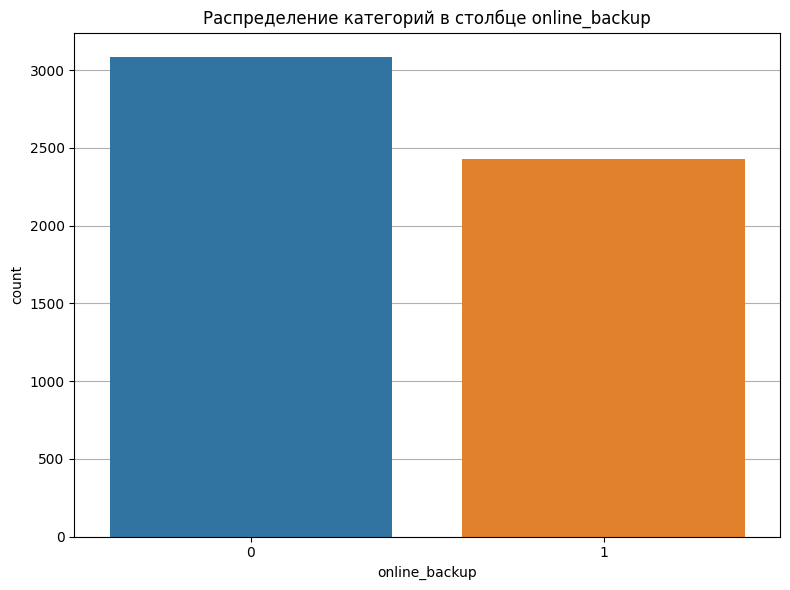

,device_protection
count,5517.00
mean,0.44
median,0.00
max,1.00
min,0.00


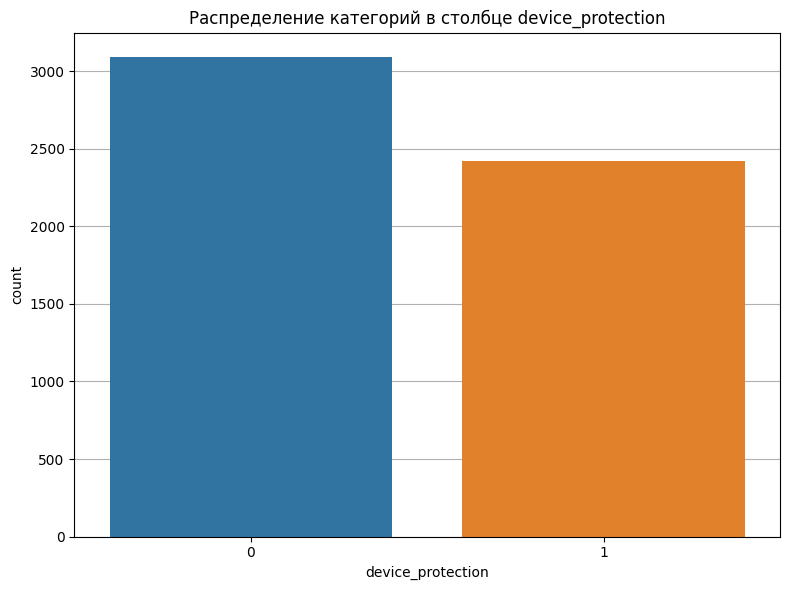

,tech_support
count,5517.00
mean,0.37
median,0.00
max,1.00
min,0.00


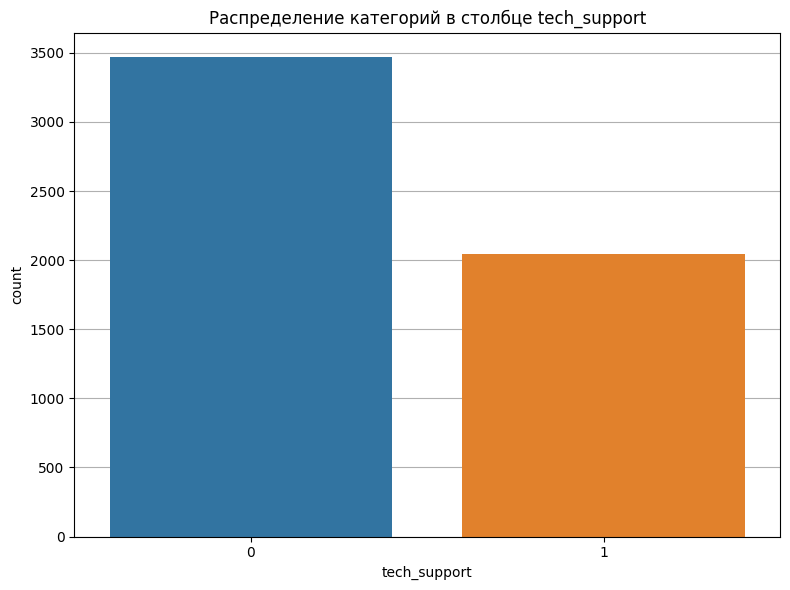

,streaming_tv
count,5517.00
mean,0.49
median,0.00
max,1.00
min,0.00


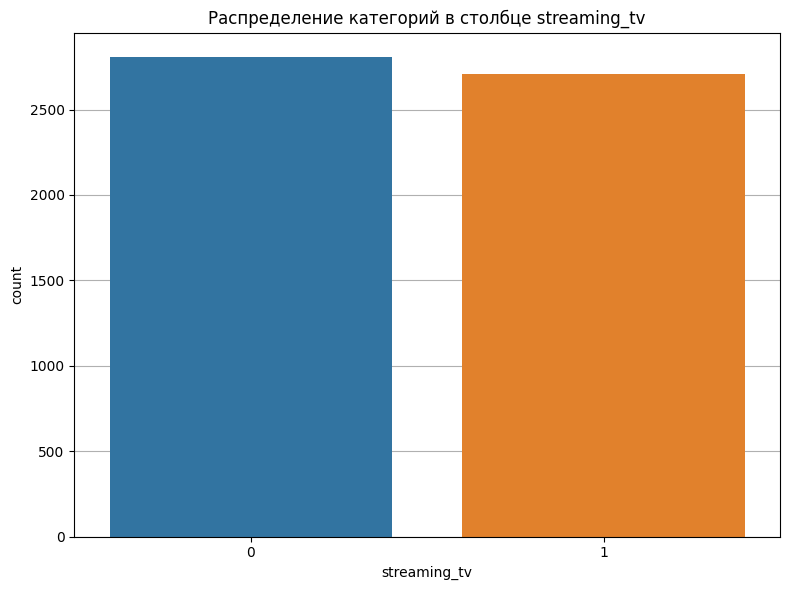

,streaming_movies
count,5517.0
mean,0.5
median,0.0
max,1.0
min,0.0


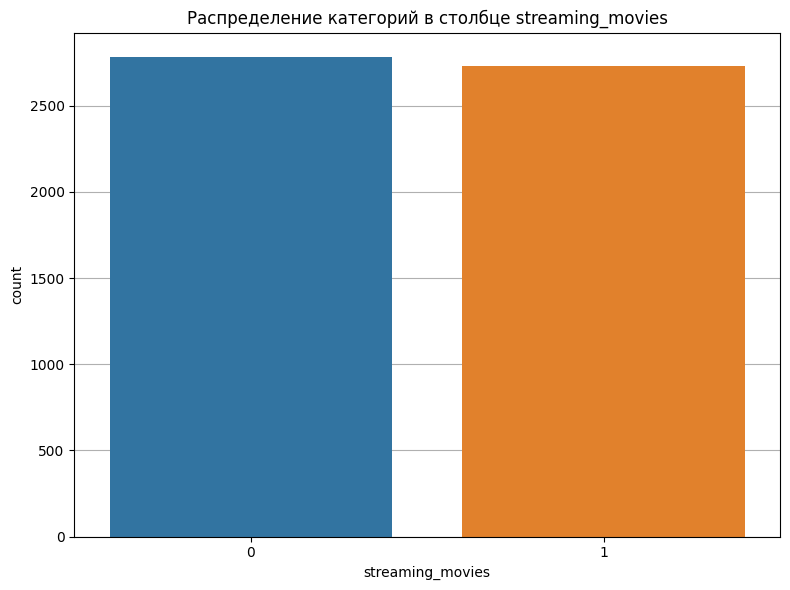


=== Анализ категориальных столбцов ===

Пропуск анализа столбца customer_id (customer_id), так как он содержит уникальные идентификаторы.


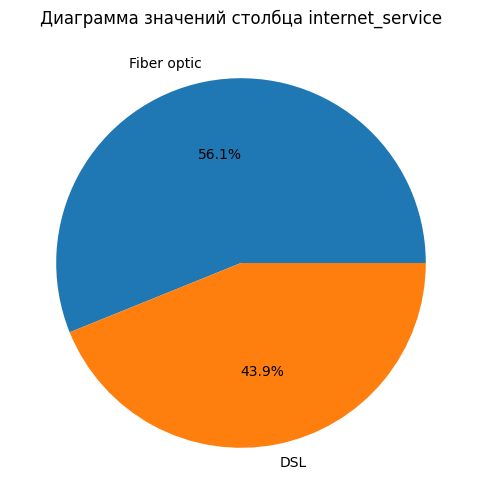


=== Завершено ===


In [9]:
# Переименование столбцов
internet_df.rename(
    columns={
        'customerID': 'customer_id', 
        'InternetService': 'internet_service', 
        'OnlineSecurity': 'online_security',
        'OnlineBackup': 'online_backup',
        'DeviceProtection': 'device_protection', 
        'TechSupport': 'tech_support',
        'StreamingTV': 'streaming_tv', 
        'StreamingMovies': 'streaming_movies'
    }, 
    inplace=True
)

# Преобразование в 0/1
bool_cols = ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']
internet_df[bool_cols] = internet_df[bool_cols].applymap(mixed_to_binary)

# Проверка дубликатов по ключевому полю customer_id
print('Дубликаты по customer_id:', internet_df['customer_id'].duplicated().sum())

# Вывод самих дублированных строк (если есть)
if internet_df.duplicated().sum() > 0:
    print("\nПримеры дубликатов:")
    display(internet_df[internet_df.duplicated(keep=False)].sort_values('customer_id').head())
else:
    print("\nДубликатов не обнаружено")

# Вывод общей информации и графиков    
print_table_info(internet_df, 'phone_df')
analyze_dataframe(internet_df, 'Распределение признаков')

### Промежуточные выводы:

* `online_security`, `tech_support` - клиентов, использующих эти услуги, примерно в два раза меньше. 
* `online_backup`, `device_protection` - клиентов, использующих эти услуги, меньше примерно на пятую часть. 
* `streaming_tv`, `streaming_movies` - клиентов, использующих эти услуги, примерно поровну с теми клиентами, которые эту услугу не используют. 
* `internet_service` - больше половины клиентов используют оптоволоконные линии связи.

Датафрейм `phone_df`:

* пропуски в данных отсутствуют;
* имена столбцов приведём к стандартному виду;
* столбец `multiple_lines` преобразуем в булевы значения;
* проверим датасет на дубликаты. Если они есть, удалим их.

Дубликаты по customer_id: 0

Дубликатов не обнаружено

Анализ таблицы: phone_df
Всего записей: 6361

Первые 5 строк:


,customer_id,multiple_lines
0,5575-GNVDE,0
1,3668-QPYBK,0
2,9237-HQITU,0
3,9305-CDSKC,1
4,1452-KIOVK,1



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 99.5+ KB
None

=== Анализ DataFrame: Распределение признаков ===

=== Анализ временнЫх столбцов ===

=== Анализ числовых столбцов ===


,multiple_lines
count,6361.00
mean,0.47
median,0.00
max,1.00
min,0.00


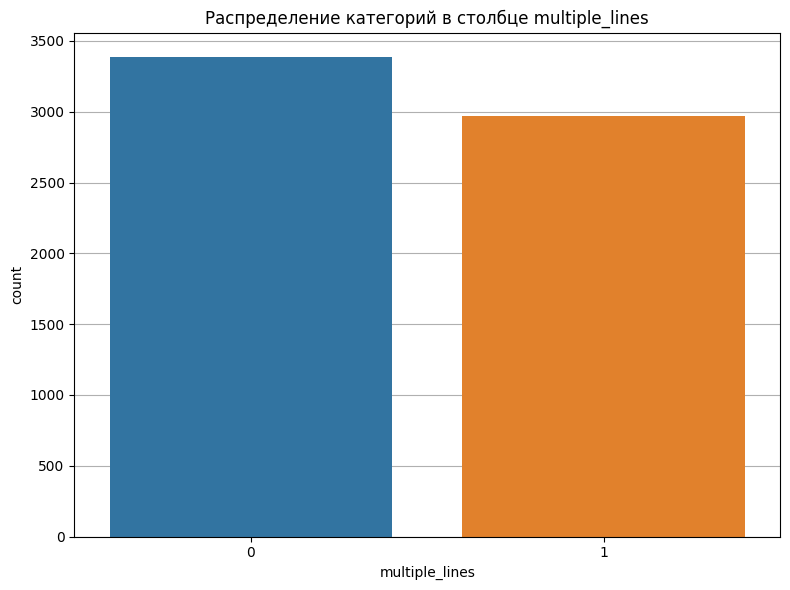


=== Анализ категориальных столбцов ===

Пропуск анализа столбца customer_id (customer_id), так как он содержит уникальные идентификаторы.

=== Завершено ===


In [10]:
# Переименование столбцов
phone_df.rename(
    columns={
        'CustomerId': 'customer_id', 
        'MultipleLines': 'multiple_lines'
    }, 
    inplace=True
)

# Преобразование в 0/1
phone_df['multiple_lines'] = phone_df['multiple_lines'].map(mixed_to_binary)

# Проверка дубликатов по ключевому полю customer_id
print('Дубликаты по customer_id:', phone_df['customer_id'].duplicated().sum())

# Вывод самих дублированных строк (если есть)
if phone_df.duplicated().sum() > 0:
    print("\nПримеры дубликатов:")
    display(phone_df[phone_df.duplicated(keep=False)].sort_values('customer_id').head())
else:
    print("\nДубликатов не обнаружено")

# Вывод общей информации и графиков    
print_table_info(phone_df, 'phone_df')
analyze_dataframe(phone_df, 'Распределение признаков')

### Промежуточные выводы:

* `multiple_lines` - клиентов, использующих эту услугу, примерно поровну с теми клиентами, которые эту услугу не используют. 

Объединим датасеты в итоговый. После объединения скорректируем форматы данных.

In [11]:
# Объединяем все датафреймы через outer join
final_df = (
    contract_df
    .merge(personal_df, on='customer_id', how='outer')
    .merge(internet_df, on='customer_id', how='outer')
    .merge(phone_df, on='customer_id', how='outer')
)

# Преобразуем к pandas-типу datetime
final_df['begin_date'] = pd.to_datetime(final_df['begin_date'])
final_df['end_date'] = pd.to_datetime(final_df['end_date'])

print_table_info(final_df, 'final')


Анализ таблицы: final
Всего записей: 7043

Первые 5 строк:


,customer_id,begin_date,end_date,type_pay,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,29.85,31.04,Female,0,1,0,DSL,0.0,1.0,0.0,0.0,0.0,0.0,NaN
1,5575-GNVDE,2017-04-01,2020-02-01,One year,0,Mailed check,56.95,2071.84,Male,0,0,0,DSL,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,1,Mailed check,53.85,226.17,Male,0,0,0,DSL,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7795-CFOCW,2016-05-01,2020-02-01,One year,0,Bank transfer (automatic),42.30,1960.60,Male,0,0,0,DSL,1.0,0.0,1.0,1.0,0.0,0.0,NaN
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,1,Electronic check,70.70,353.50,Female,0,0,0,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type_pay           7043 non-null   object        
 4   paperless_billing  7043 non-null   int64         
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior             7043 non-null   int64         
 10  partner            7043 non-null   int64         
 11  dependents         7043 non-null   int64         
 12  internet_service   5517 non-null   object        
 13  online_security    5517 non-null   floa

Заметим, что у нас появились пропуски. Это можно объяснить тем, что не все пользователи используют интернет и не все используют телефонную связь (подключение телефона к нескольким линиям одновременно не используется в виду отсутствия собственно телефона). Чтобы не допустить смешивания различных абонентов, заполним пропуски заглушкой `not_use`.

In [12]:
#Заполним пропуски в данных 0/1
not_use_cols = ['internet_service', 'online_security', 'online_backup', 'device_protection',
             'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']

for col in not_use_cols:
    final_df[col] = final_df[col].fillna('not_use')

print_table_info(final_df, 'final')


Анализ таблицы: final
Всего записей: 7043

Первые 5 строк:


,customer_id,begin_date,end_date,type_pay,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,29.85,31.04,Female,0,1,0,DSL,0.0,1.0,0.0,0.0,0.0,0.0,not_use
1,5575-GNVDE,2017-04-01,2020-02-01,One year,0,Mailed check,56.95,2071.84,Male,0,0,0,DSL,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,1,Mailed check,53.85,226.17,Male,0,0,0,DSL,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7795-CFOCW,2016-05-01,2020-02-01,One year,0,Bank transfer (automatic),42.30,1960.60,Male,0,0,0,DSL,1.0,0.0,1.0,1.0,0.0,0.0,not_use
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,1,Electronic check,70.70,353.50,Female,0,0,0,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type_pay           7043 non-null   object        
 4   paperless_billing  7043 non-null   int64         
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior             7043 non-null   int64         
 10  partner            7043 non-null   int64         
 11  dependents         7043 non-null   int64         
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   obje

Выделим в целевую переменную признак `end_date` и создадим дополнительные признаки.

Новые признаки:
* `contract_duration` - длительность контракта в месяцах.
* `num_extra_services` - количество дополнительных услуг.
* `streaming_active` — активность стриминга.
* `enior_family` — выявляет специфику пожилых клиентов с семьей.
* `family_size` - размер семьи.

In [13]:
def create_features(df, streaming_flag=True):
    """Создает новые признаки с учетом заглушки 'not_use'."""

    # contract_duration (без проверки на 'not_use')
    df['contract_duration'] = np.where(
        pd.isna(df['end_date']) | pd.isna(df['begin_date']),
        np.nan,
        (df['end_date'] - df['begin_date']).dt.days / 30
    )

    # streaming_active (с проверкой на 'not_use', управляется флагом)
    if streaming_flag:
        df['streaming_active'] = np.where(
            (df['streaming_tv'] == 'not_use') | (df['streaming_movies'] == 'not_use'),
            'not_use',
            df['streaming_tv'] + df['streaming_movies']
        )
    else:
        df['streaming_active'] = df['streaming_tv'] + df['streaming_movies']

    # family_size (без проверки на 'not_use')
    df['family_size'] = df['partner'] + df['dependents']

    # senior_family (без проверки на 'not_use')
    df['senior_family'] = df['senior'] * df['family_size']

    # num_extra_services (учитываем not_use во всех столбцах)
    def count_services(row):
        all_not_use = True
        count = 0
        for col in ['online_security', 'online_backup', 'device_protection',
                    'tech_support', 'streaming_tv', 'streaming_movies']:
            if row[col] != 'not_use':
                all_not_use = False
                if row[col] == 1:  # Считаем только значения, равные 1
                    count += 1
        if all_not_use:
            return 'not_use'
        else:
            return count

    df['num_extra_services'] = df[['online_security', 'online_backup', 'device_protection',
                                  'tech_support', 'streaming_tv', 'streaming_movies']].apply(count_services, axis=1)

    return df

# Применяем функцию к DataFrame
final_df = create_features(final_df.copy())  # Передаем копию, чтобы избежать SettingWithCopyWarning

# Целевая переменная
final_df['target'] = (final_df['end_date'] != '2020-02-01').astype(int)

In [14]:
print("\nУникальные значения в столбцах:")
for col in final_df.columns:
    print(f"{col}: {final_df[col].nunique()} уникальных значений")


Уникальные значения в столбцах:
customer_id: 7043 уникальных значений
begin_date: 77 уникальных значений
end_date: 67 уникальных значений
type_pay: 3 уникальных значений
paperless_billing: 2 уникальных значений
payment_method: 4 уникальных значений
monthly_charges: 1585 уникальных значений
total_charges: 6658 уникальных значений
gender: 2 уникальных значений
senior: 2 уникальных значений
partner: 2 уникальных значений
dependents: 2 уникальных значений
internet_service: 3 уникальных значений
online_security: 3 уникальных значений
online_backup: 3 уникальных значений
device_protection: 3 уникальных значений
tech_support: 3 уникальных значений
streaming_tv: 3 уникальных значений
streaming_movies: 3 уникальных значений
multiple_lines: 3 уникальных значений
contract_duration: 251 уникальных значений
streaming_active: 4 уникальных значений
family_size: 3 уникальных значений
senior_family: 3 уникальных значений
num_extra_services: 8 уникальных значений
target: 2 уникальных значений


## Исследовательский анализ данных

Проведём исследовательский анализ общей таблицы.


Анализ таблицы: phone_df
Всего записей: 7043

Первые 5 строк:


,customer_id,begin_date,end_date,type_pay,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,contract_duration,streaming_active,family_size,senior_family,num_extra_services,target
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,29.85,31.04,Female,0,1,0,DSL,0.0,1.0,0.0,0.0,0.0,0.0,not_use,1.033333,0.0,1,0,1,0
1,5575-GNVDE,2017-04-01,2020-02-01,One year,0,Mailed check,56.95,2071.84,Male,0,0,0,DSL,1.0,0.0,1.0,0.0,0.0,0.0,0.0,34.533333,0.0,0,0,2,0
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,1,Mailed check,53.85,226.17,Male,0,0,0,DSL,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.100000,0.0,0,0,2,0
3,7795-CFOCW,2016-05-01,2020-02-01,One year,0,Bank transfer (automatic),42.30,1960.60,Male,0,0,0,DSL,1.0,0.0,1.0,1.0,0.0,0.0,not_use,45.700000,0.0,0,0,3,0
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,1,Electronic check,70.70,353.50,Female,0,0,0,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.100000,0.0,0,0,0,0



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         7043 non-null   object        
 1   begin_date          7043 non-null   datetime64[ns]
 2   end_date            7043 non-null   datetime64[ns]
 3   type_pay            7043 non-null   object        
 4   paperless_billing   7043 non-null   int64         
 5   payment_method      7043 non-null   object        
 6   monthly_charges     7043 non-null   float64       
 7   total_charges       7043 non-null   float64       
 8   gender              7043 non-null   object        
 9   senior              7043 non-null   int64         
 10  partner             7043 non-null   int64         
 11  dependents          7043 non-null   int64         
 12  internet_service    7043 non-null   object        
 13  online_security     7043

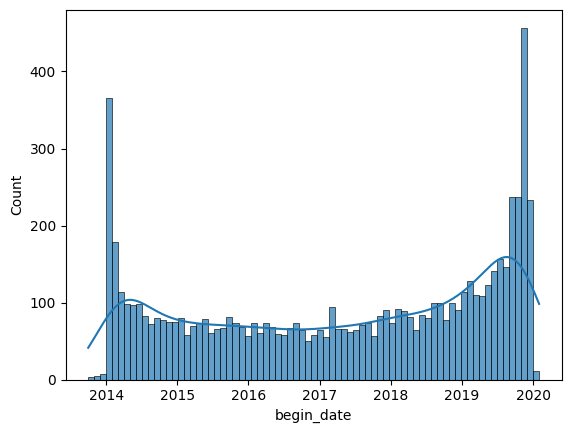

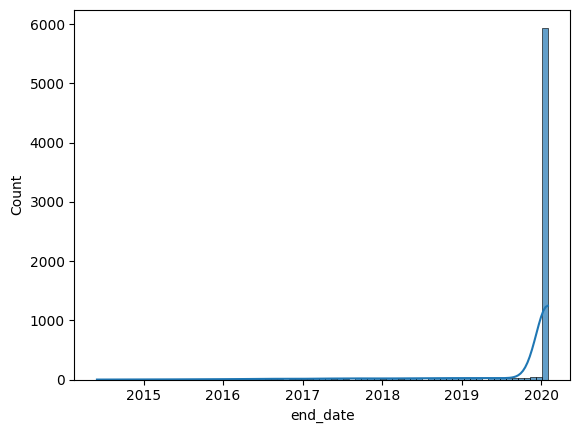


=== Анализ числовых столбцов ===


,paperless_billing
count,7043.00
mean,0.59
median,1.00
max,1.00
min,0.00


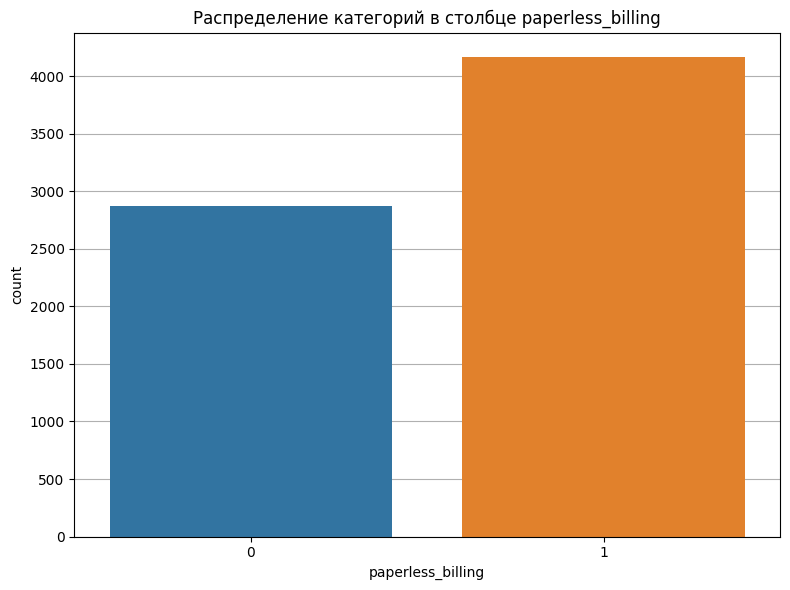

,monthly_charges
count,7043.00
mean,64.76
median,70.35
max,118.75
min,18.25


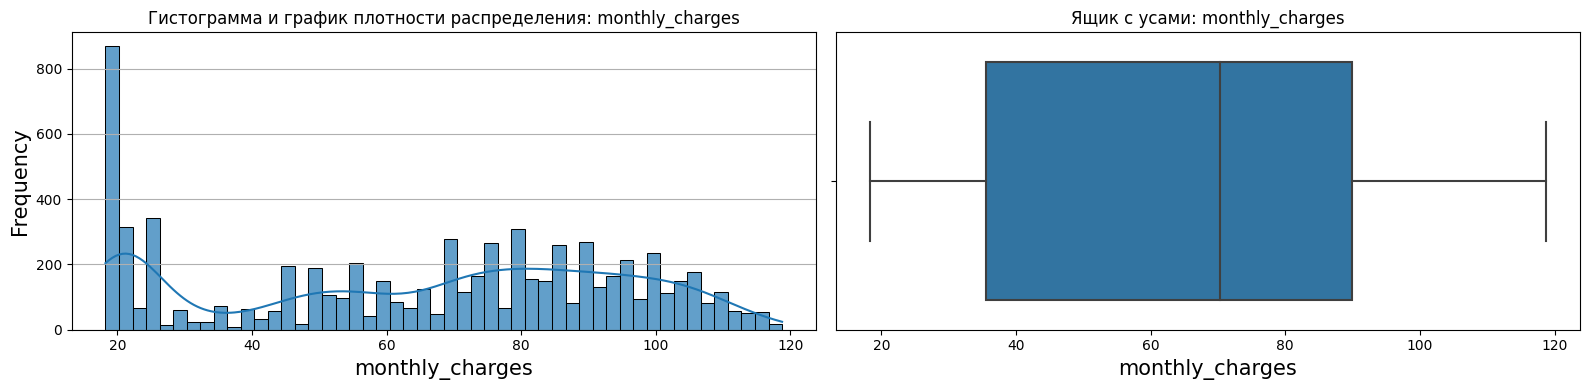

,total_charges
count,7043.00
mean,2115.31
median,1343.35
max,9221.38
min,0.00


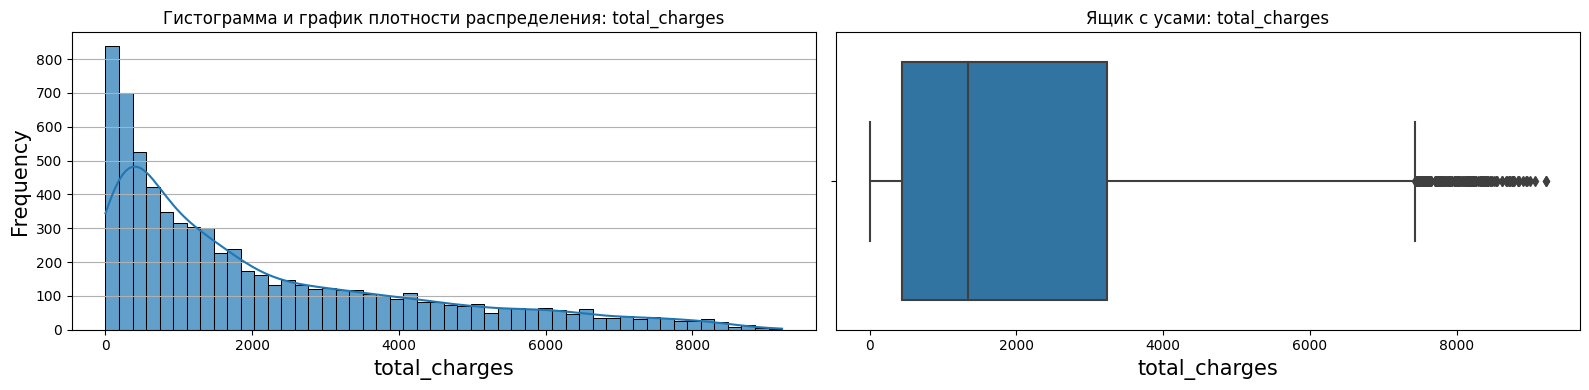

,senior
count,7043.00
mean,0.16
median,0.00
max,1.00
min,0.00


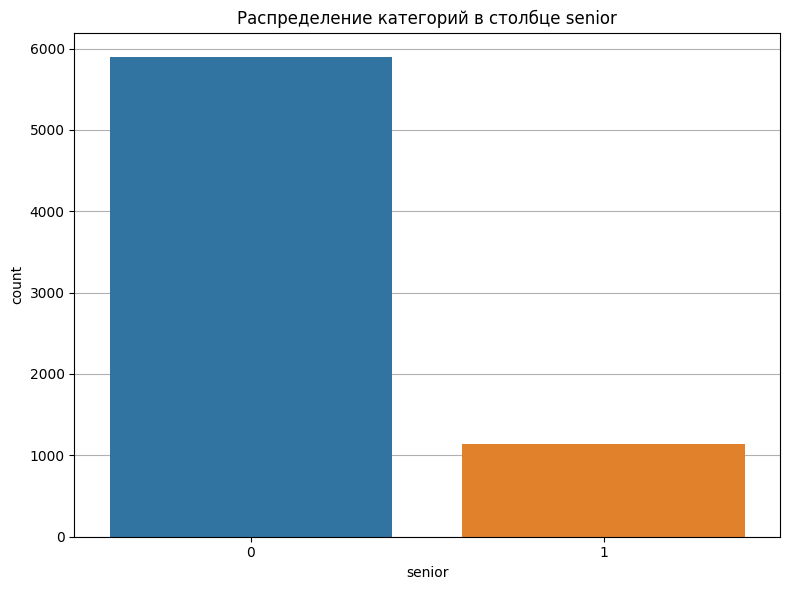

,partner
count,7043.00
mean,0.48
median,0.00
max,1.00
min,0.00


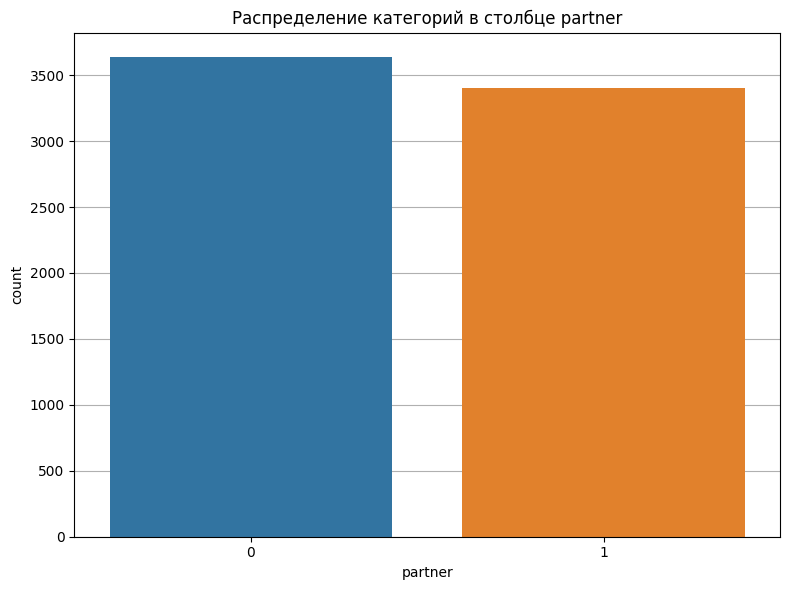

,dependents
count,7043.0
mean,0.3
median,0.0
max,1.0
min,0.0


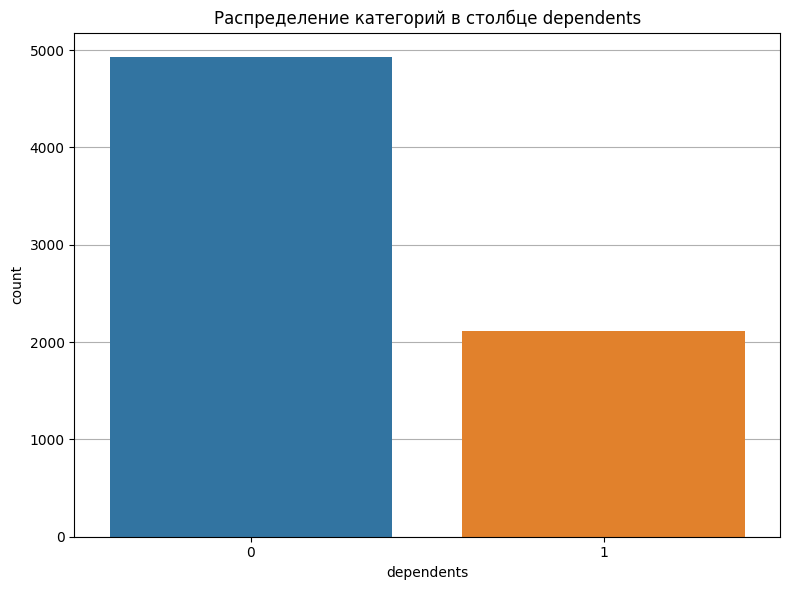

,contract_duration
count,7043.00
mean,29.95
median,25.37
max,77.13
min,0.00


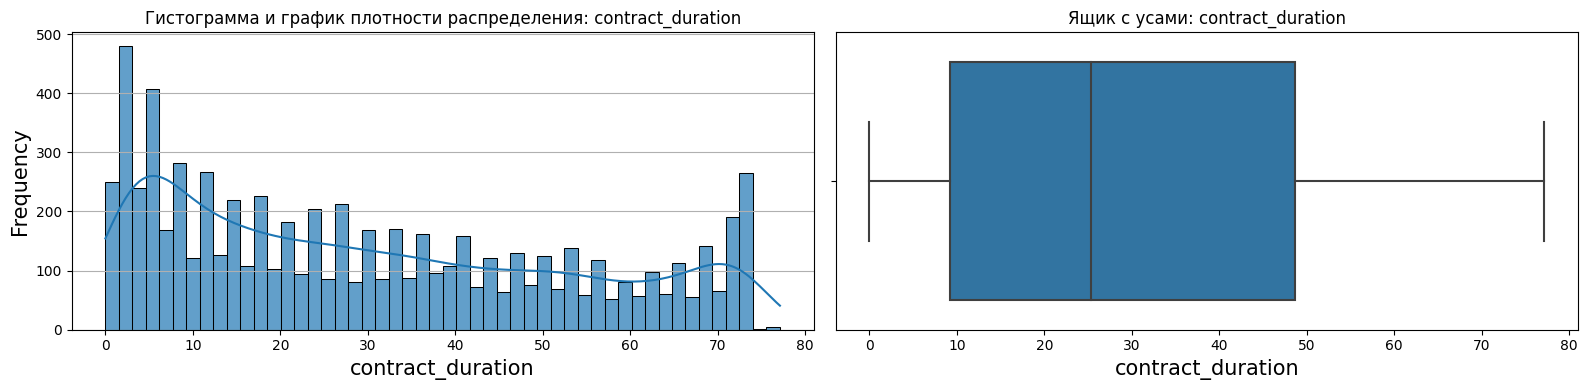

,family_size
count,7043.00
mean,0.78
median,1.00
max,2.00
min,0.00


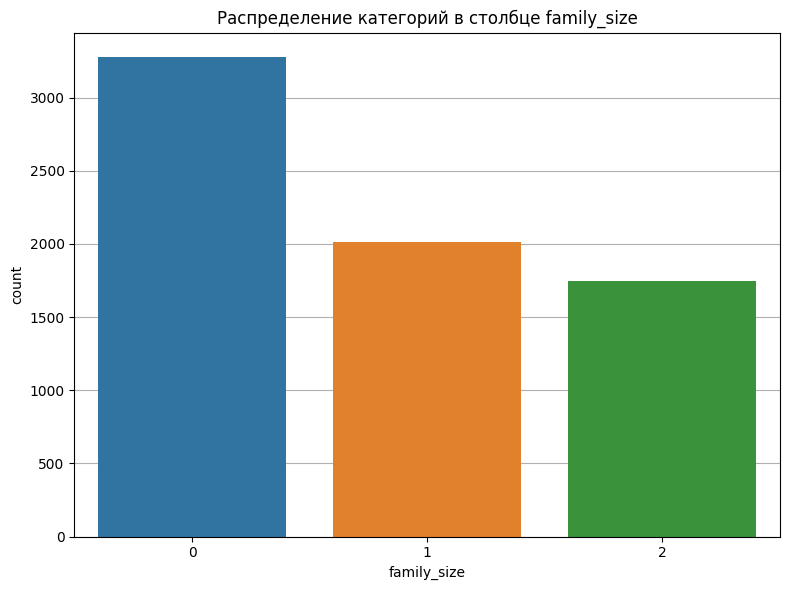

,senior_family
count,7043.00
mean,0.09
median,0.00
max,2.00
min,0.00


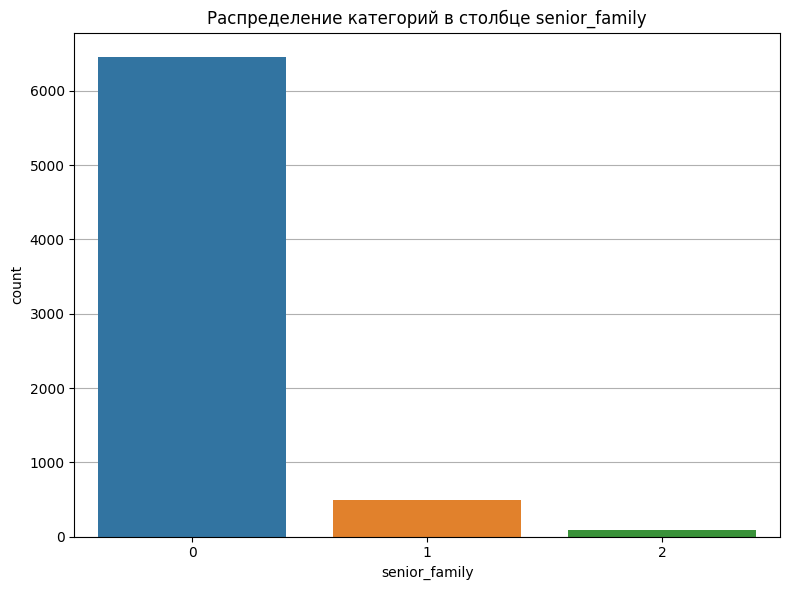

,target
count,7043.00
mean,0.16
median,0.00
max,1.00
min,0.00


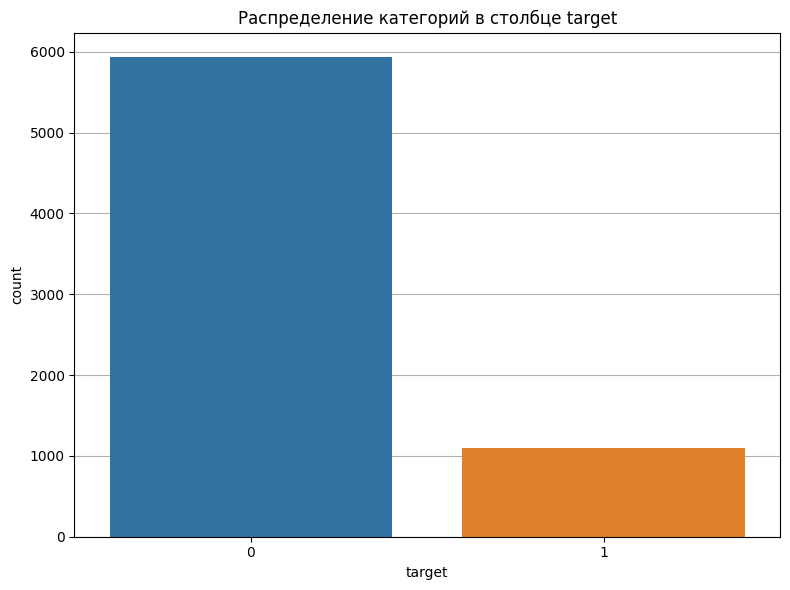


=== Анализ категориальных столбцов ===

Пропуск анализа столбца customer_id (customer_id), так как он содержит уникальные идентификаторы.


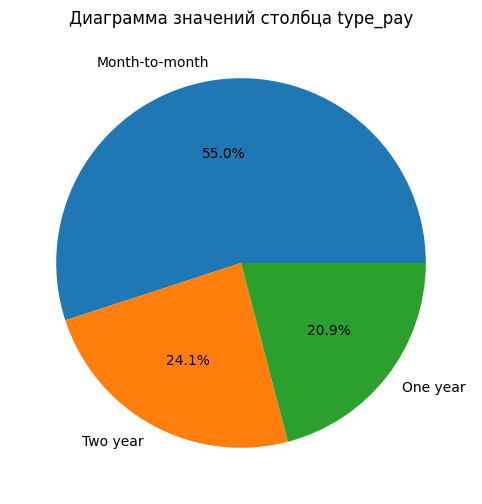

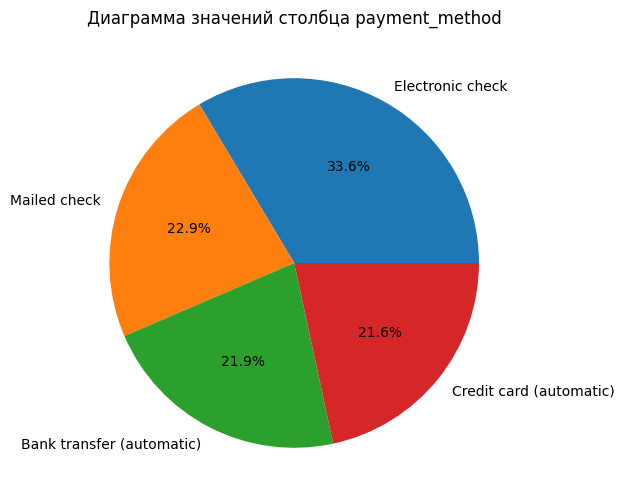

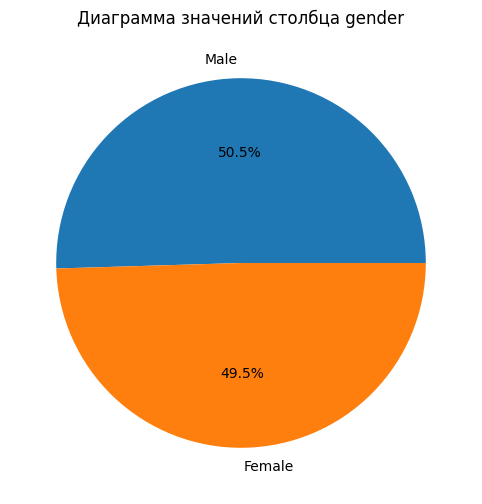

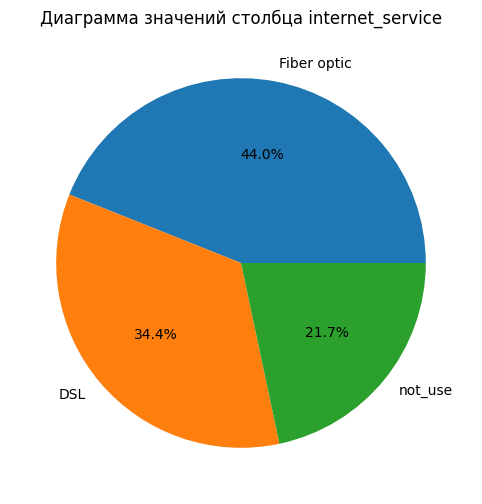

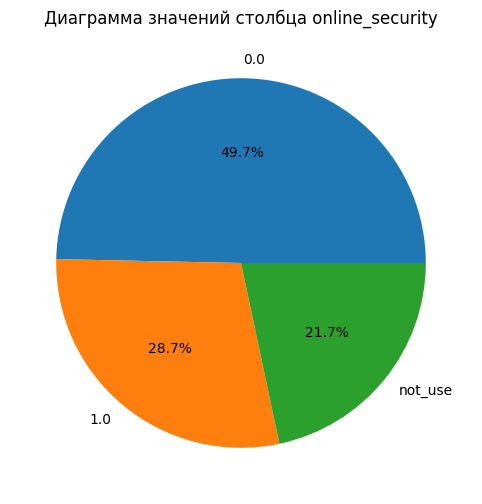

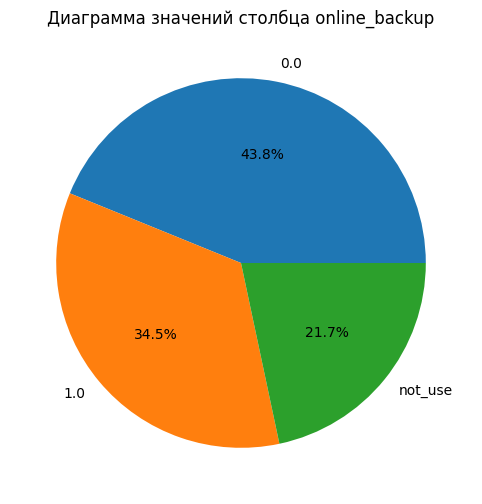

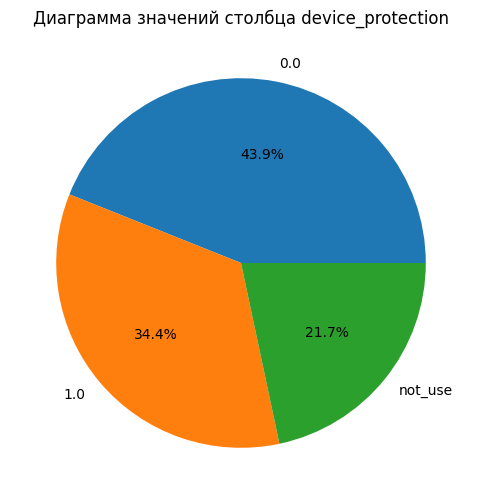

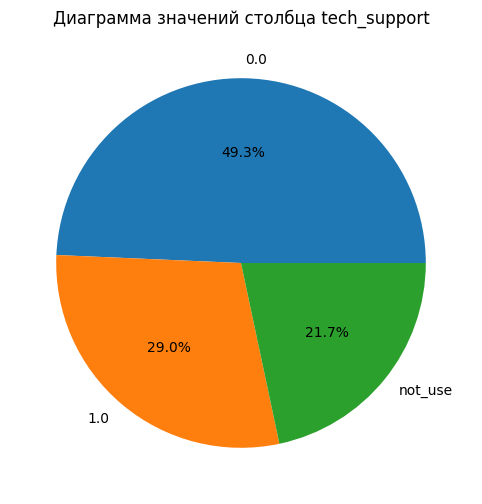

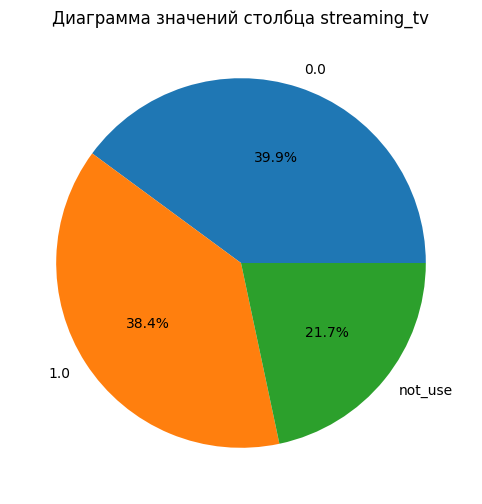

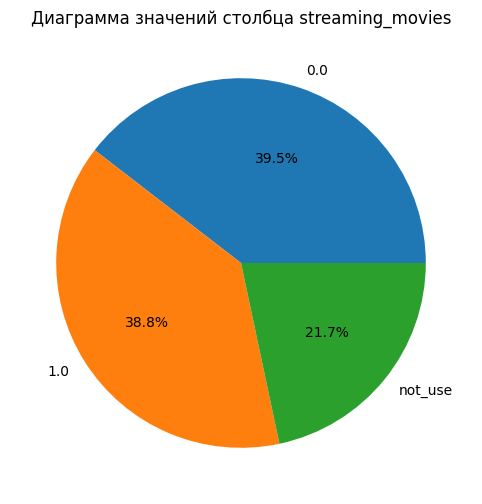

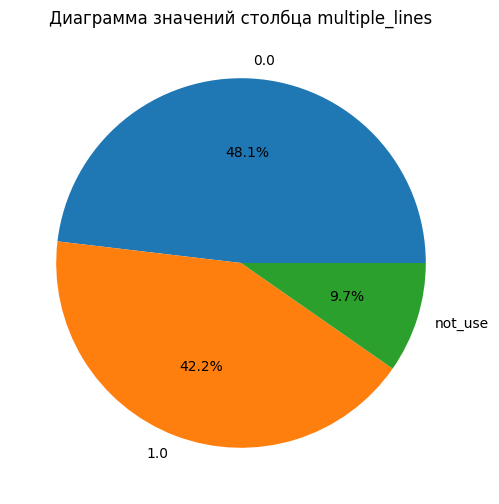

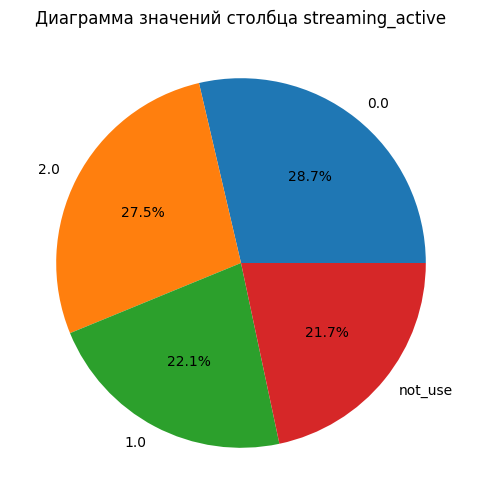

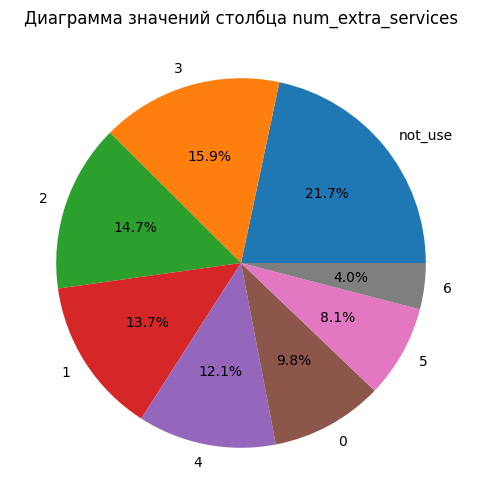


=== Завершено ===


In [15]:
# Вывод общей информации и графиков    
print_table_info(final_df, 'phone_df')
analyze_dataframe(final_df, 'Распределение признаков')

Визуализируем соотношение ушедших и оставшихся клиентов для каждого признака:

In [16]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         7043 non-null   object        
 1   begin_date          7043 non-null   datetime64[ns]
 2   end_date            7043 non-null   datetime64[ns]
 3   type_pay            7043 non-null   object        
 4   paperless_billing   7043 non-null   int64         
 5   payment_method      7043 non-null   object        
 6   monthly_charges     7043 non-null   float64       
 7   total_charges       7043 non-null   float64       
 8   gender              7043 non-null   object        
 9   senior              7043 non-null   int64         
 10  partner             7043 non-null   int64         
 11  dependents          7043 non-null   int64         
 12  internet_service    7043 non-null   object        
 13  online_security     7043 non-null   object      

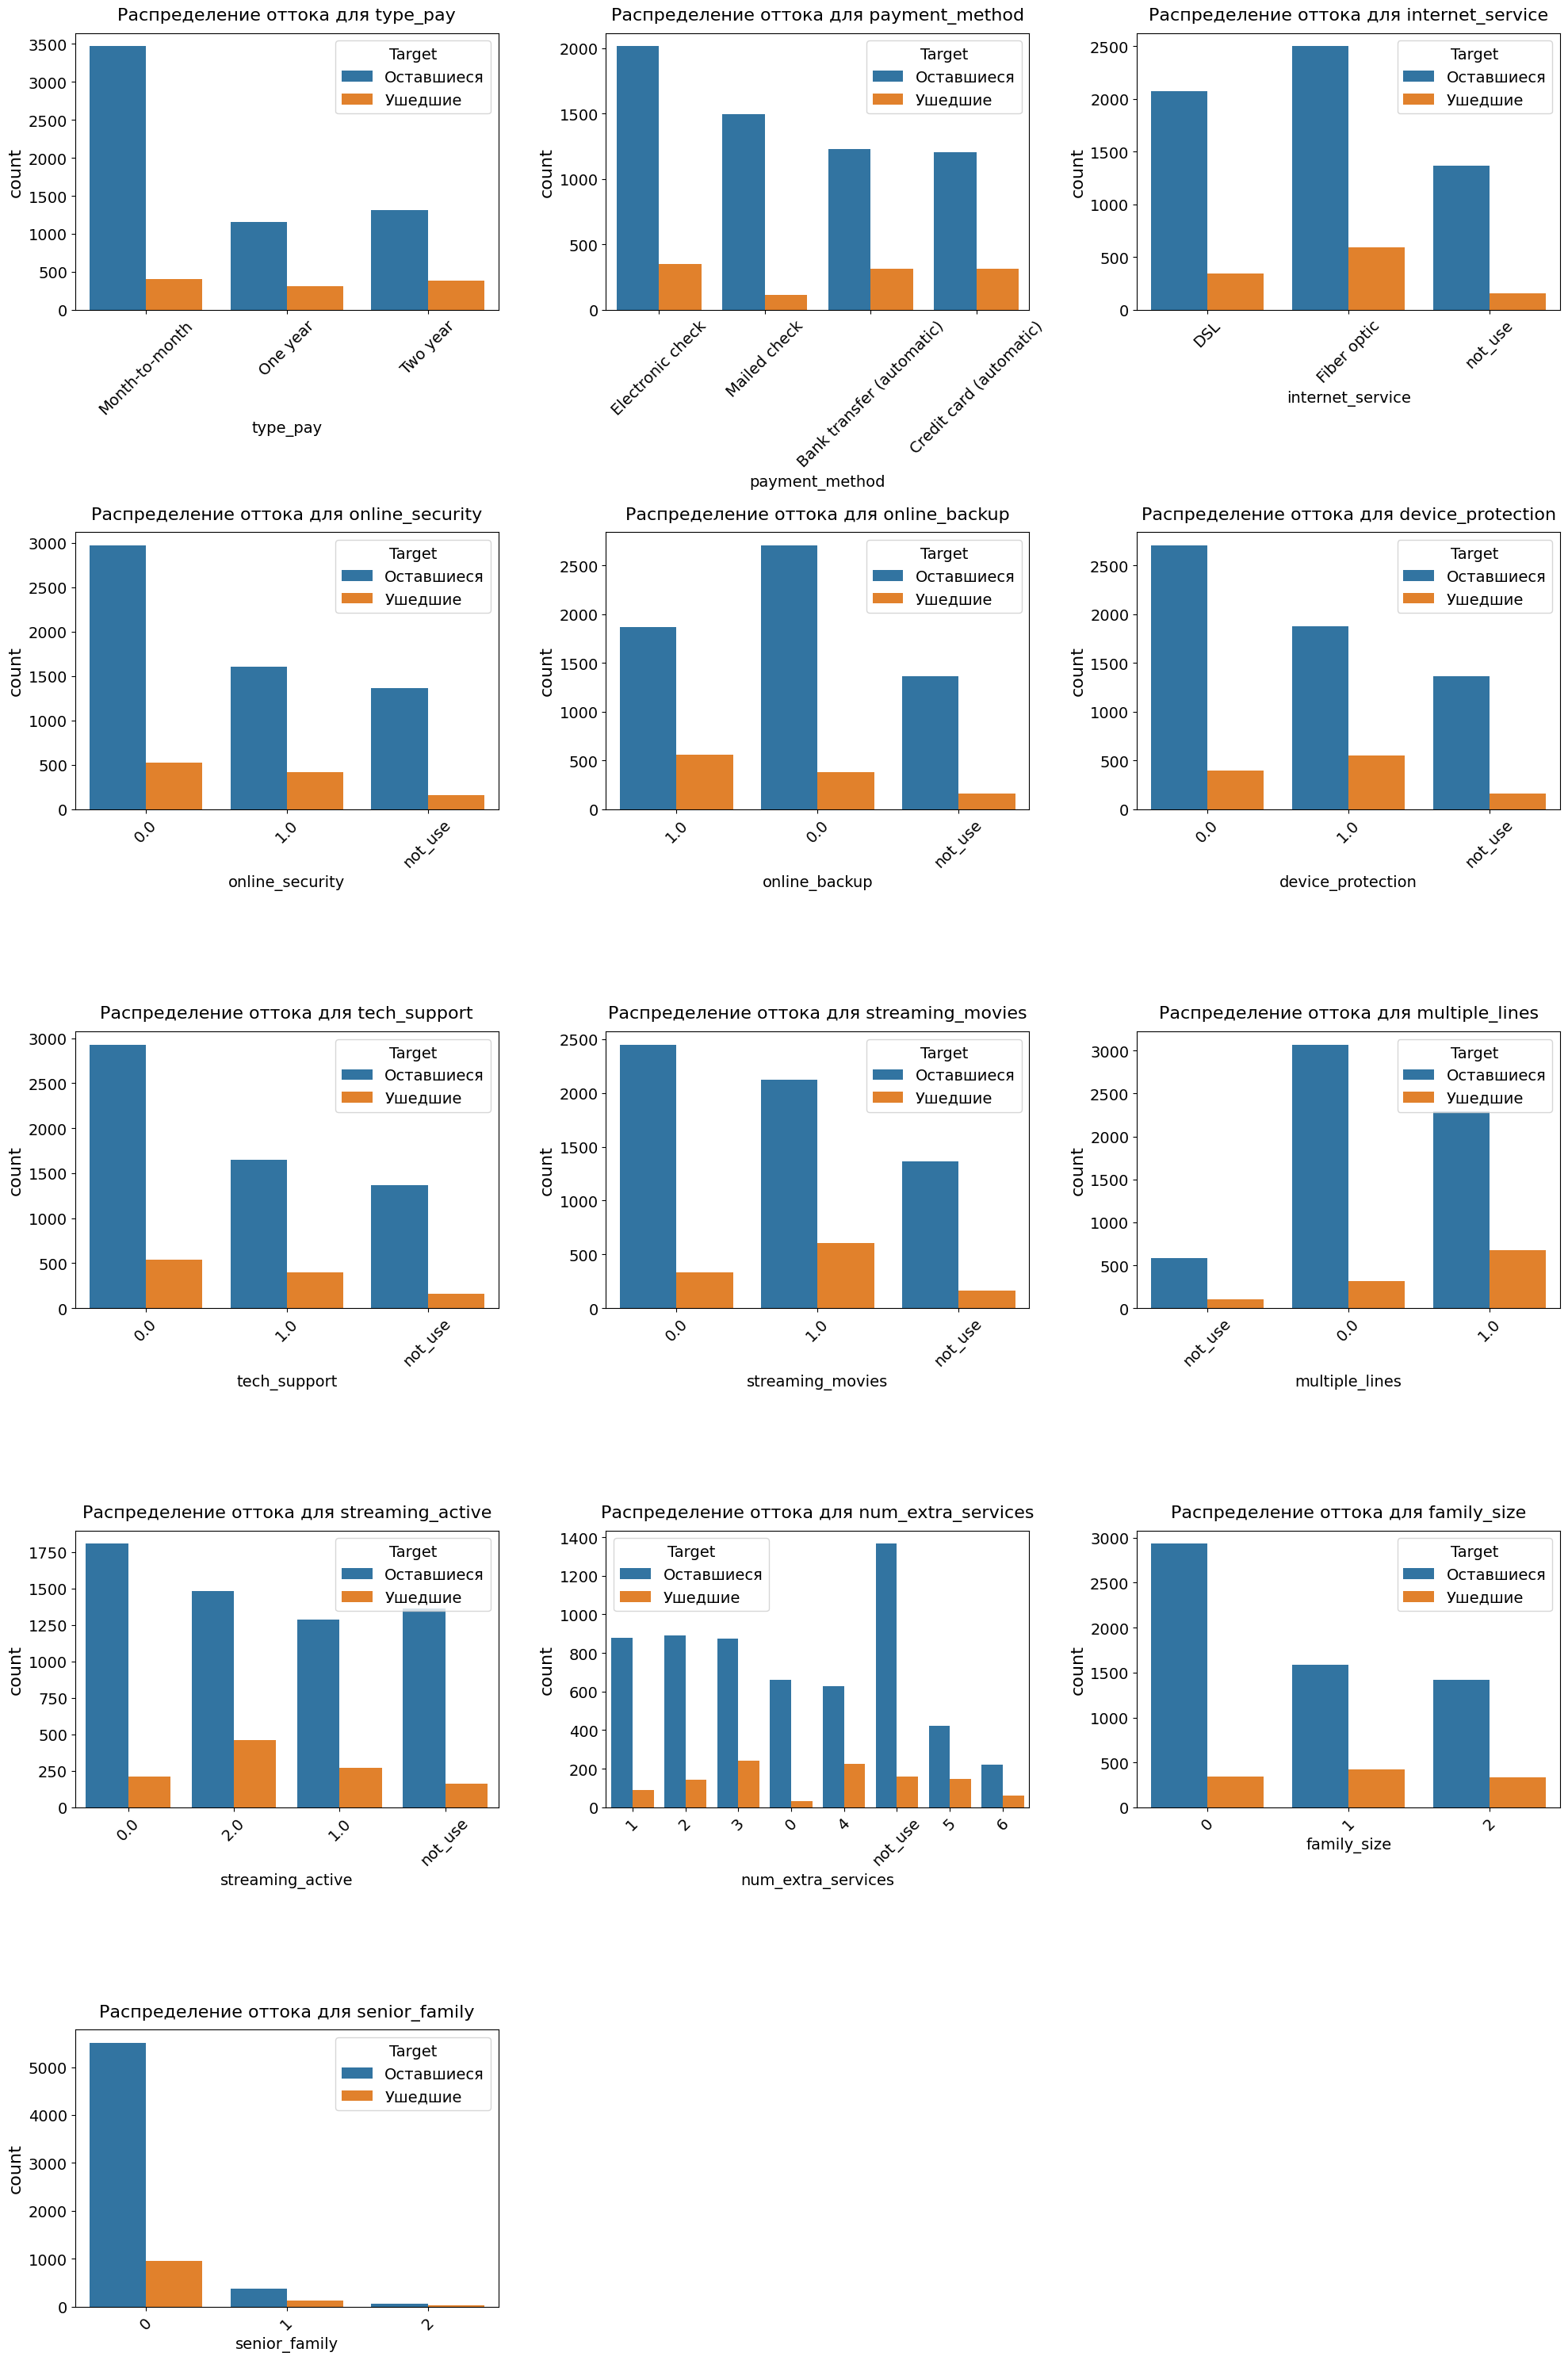

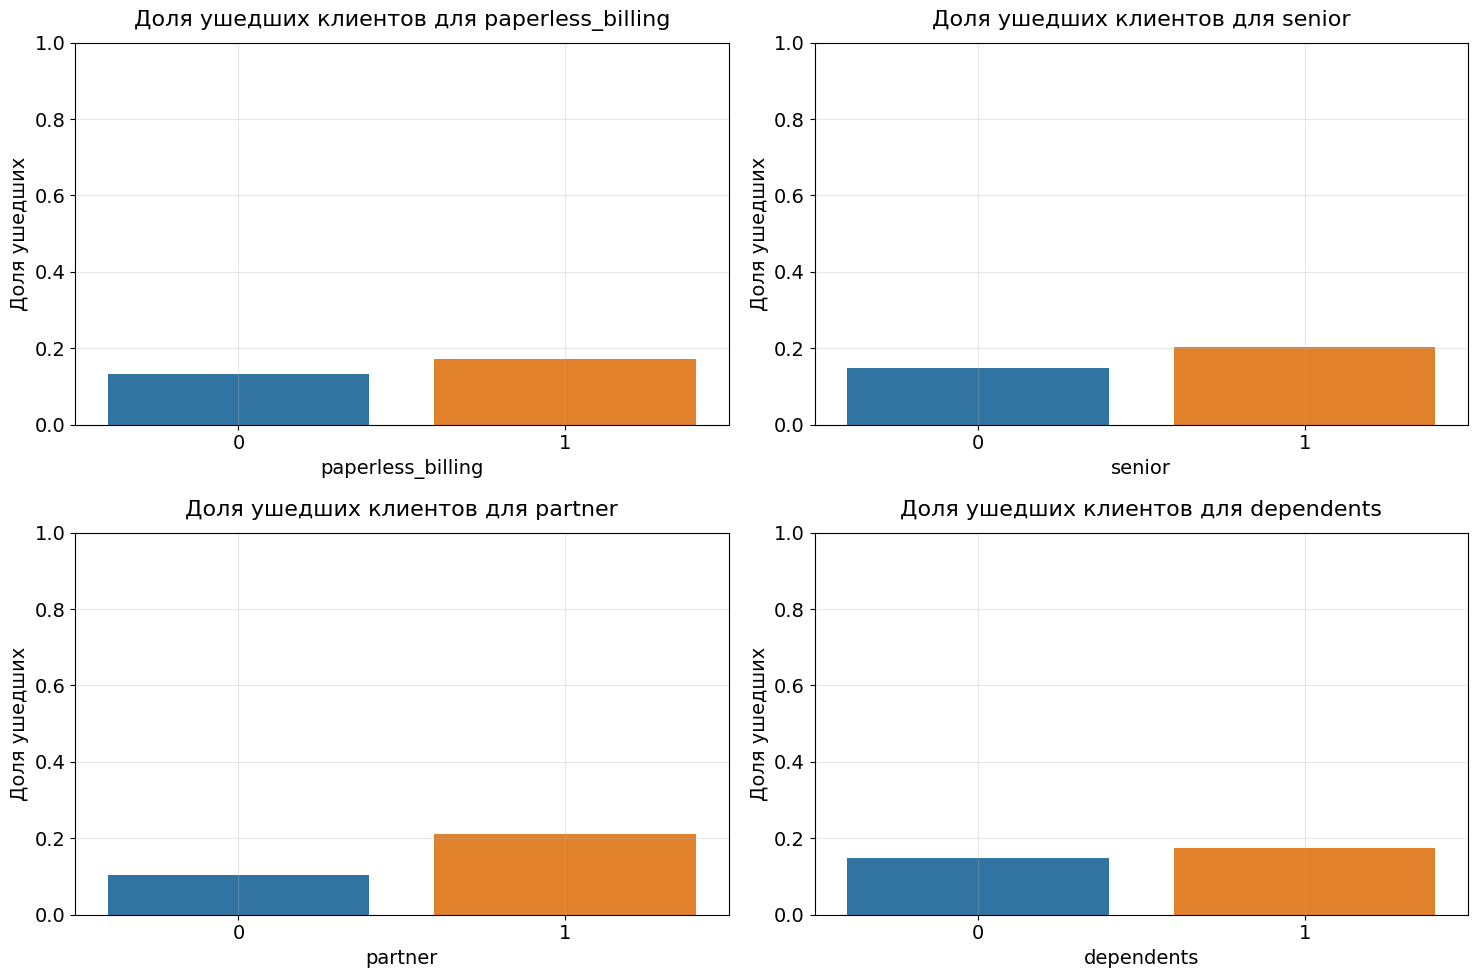

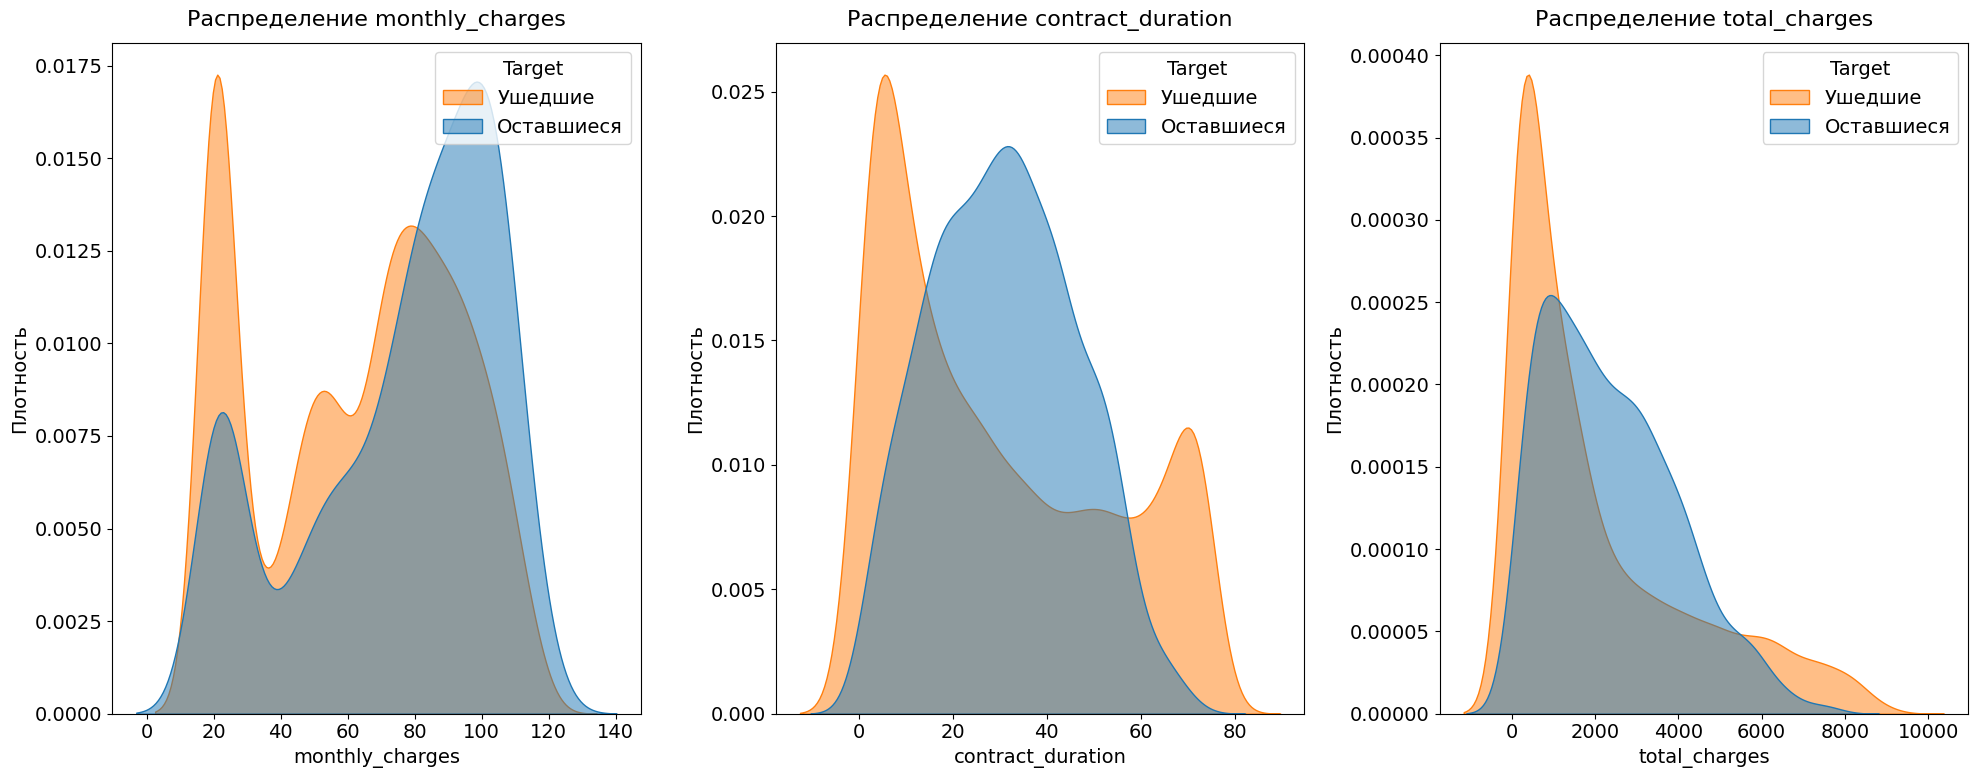

In [17]:
# Определение категорий признаков
cat_features = [
    'type_pay',
    'payment_method',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_movies',
    'multiple_lines',
    'streaming_active',
    'num_extra_services',
    'family_size',
    'senior_family'
]
binary_features = [
    'paperless_billing',
    'senior',
    'partner',
    'dependents'
]

numeric_features = [
    'monthly_charges',
    'contract_duration',
    'total_charges'
]
# Преобразуем категориальные признаки в строковый тип
for col in cat_features:
    final_df[col] = final_df[col].astype(str)

    # Настройка размеров шрифтов
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Визуализация категориальных признаков с сортировкой по значению
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 30))
for i, col in enumerate(cat_features, 1):
    plt.subplot(5, 3, i)  # 5 строк, 3 столбца

    # Специальная обработка для порядковых категорий
    if col in ['family_size', 'senior_family']:
        order = sorted(final_df[col].unique(), key=lambda x: float(x) if x.replace('.','',1).isdigit() else x)
    else:
        order = final_df[col].unique()

    sns.countplot(data=final_df, x=col, hue="target", order=order)
    plt.title(f"Распределение оттока для {col}", fontsize=16, pad=12)
    plt.xlabel(col, fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(title='Target', labels=['Оставшиеся', 'Ушедшие'])

plt.tight_layout()

# Визуализация бинарных признаков
plt.figure(figsize=(15, 10))
for i, col in enumerate(binary_features, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=final_df, x=col, y="target", errorbar=None)
    plt.title(f"Доля ушедших клиентов для {col}", fontsize=16, pad=12)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("Доля ушедших", fontsize=14)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)

plt.tight_layout()

# Визуализация числовых признаков
plt.figure(figsize=(20, 8))  # Увеличиваем ширину, чтобы графики не перекрывались
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)  # Меняем на 1 строку и 3 столбца
    hue_order = sorted(final_df['target'].unique(), reverse=True)
    sns.kdeplot(data=final_df, x=col, hue="target", hue_order=hue_order,
                fill=True, alpha=0.5, common_norm=False)
    plt.title(f"Распределение {col}", fontsize=16, pad=12)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("Плотность", fontsize=14)
    plt.legend(title='Target', labels=['Ушедшие', 'Оставшиеся'])

plt.tight_layout()

plt.show()

### Промежуточные выводы:

* Соотношение ушедших и оставшихся клиентов практически не зависит от  `type_pay`, `internet_service`. 
* Немного ниже отток клиентов, получающих квитанции по почте, относительно других способов получения.
* Немного выше отток клиентов-пенсионеров, имеющих супруга и иждевенца.
* Также немного выше отток клиентов, которые пользовались дополнительными услугами. Это прослеживается по всем категориям.
* Большая доля ушедших приходится на тех, кто платил ежемесячно около 20, 50 и 80  у.е., а текже тех, кто суммарно заплатил от 0 до 1000 у.е. Высокая доля ушедших относительно оставшихся наблюдается при суммарных платежах от 6000-10000 у.е. 
* Большая доля ушедших приходится на тех, чья длительность обслуживания близка к первым 12 месяцам. Также есть небольшой рост отказников в районе 70 месяцев.
* Прослеживается влияние покупки дополнительных интернет-услуг: чем их больше, тем доля ушедших клиентов выше, за исключением пользователей с полным пакетом услуг.
* Наблюдается интересный факт - если человек в семье один, то выше вероятность, что он покинет провайдера. Вероятно, это связано с тем, что одинокому гораздо проще выбирать услуги для своих потребностей, не нужно считаться с мнением домочадцев.

Исключим ненужные признаки и возможные дубликаты:

* `customer_id` - в дальнейшей работе id клиента не нужен.
* `begin_date`, `end_date` - перед нами не стоит задача временных рядов.
* `gender` - удален как неинформативный (предполагается, что пол не влияет на отток).
* `streaming_movies` и `streaming_tv` сильно коррелируют, удалим один из них.

In [18]:
# Удаление ненужных колонок
final_df = final_df.drop(columns=['customer_id', 'begin_date', 'end_date', 'gender', 'streaming_tv'])

# Удаление полных дубликатов
final_df = final_df.drop_duplicates()

print_table_info(final_df, 'final')



Анализ таблицы: final
Всего записей: 7031

Первые 5 строк:


,type_pay,paperless_billing,payment_method,monthly_charges,total_charges,senior,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_movies,multiple_lines,contract_duration,streaming_active,family_size,senior_family,num_extra_services,target
0,Month-to-month,1,Electronic check,29.85,31.04,0,1,0,DSL,0.0,1.0,0.0,0.0,0.0,not_use,1.033333,0.0,1,0,1,0
1,One year,0,Mailed check,56.95,2071.84,0,0,0,DSL,1.0,0.0,1.0,0.0,0.0,0.0,34.533333,0.0,0,0,2,0
2,Month-to-month,1,Mailed check,53.85,226.17,0,0,0,DSL,1.0,1.0,0.0,0.0,0.0,0.0,4.100000,0.0,0,0,2,0
3,One year,0,Bank transfer (automatic),42.30,1960.60,0,0,0,DSL,1.0,0.0,1.0,1.0,0.0,not_use,45.700000,0.0,0,0,3,0
4,Month-to-month,1,Electronic check,70.70,353.50,0,0,0,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,5.100000,0.0,0,0,0,0



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7031 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   type_pay            7031 non-null   object 
 1   paperless_billing   7031 non-null   int64  
 2   payment_method      7031 non-null   object 
 3   monthly_charges     7031 non-null   float64
 4   total_charges       7031 non-null   float64
 5   senior              7031 non-null   int64  
 6   partner             7031 non-null   int64  
 7   dependents          7031 non-null   int64  
 8   internet_service    7031 non-null   object 
 9   online_security     7031 non-null   object 
 10  online_backup       7031 non-null   object 
 11  device_protection   7031 non-null   object 
 12  tech_support        7031 non-null   object 
 13  streaming_movies    7031 non-null   object 
 14  multiple_lines      7031 non-null   object 
 15  contract_duration   7031 non-nu

## Корреляционный анализ

Проведём корреляционный анализ признаков с помощью матрицы корреляции `phik_matrix()` и сделаем выводы о мультиколлинеарности и при необходимости устраним её. Также проверим данные на утечку целевого параметра.

interval columns not set, guessing: ['paperless_billing', 'monthly_charges', 'total_charges', 'senior', 'partner', 'dependents', 'contract_duration', 'target']


<Figure size 2000x1800 with 0 Axes>

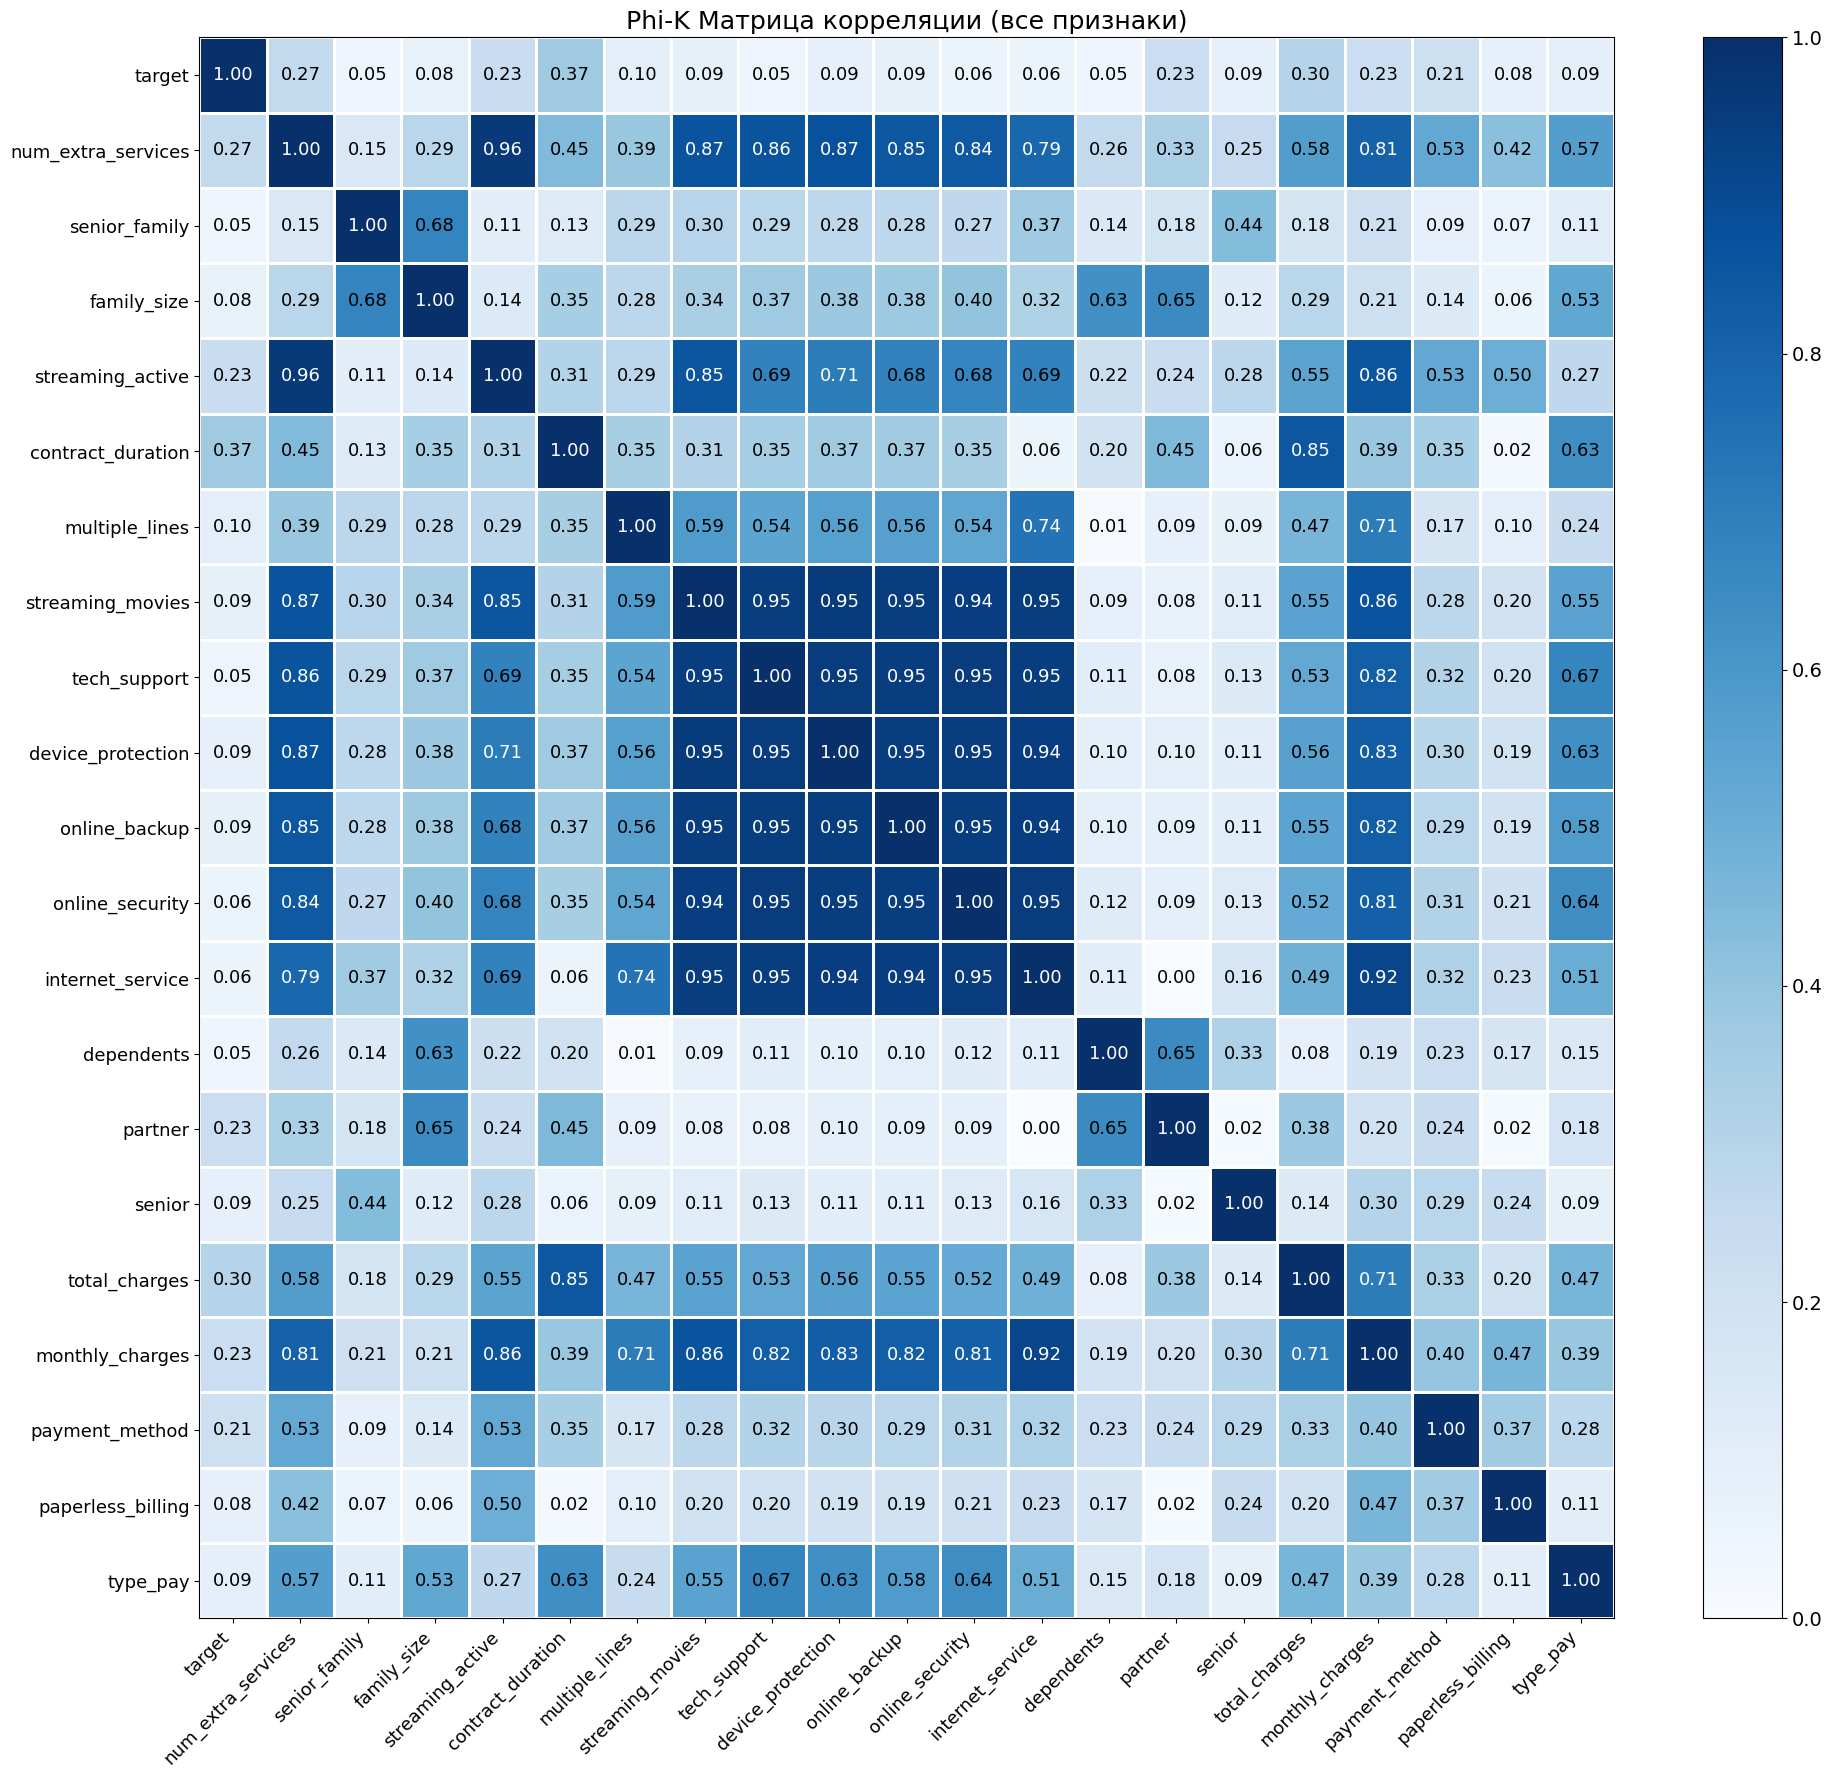

In [19]:
# Рассчитаем матрицу корреляции для всех оставшихся признаков
phik_matrix = final_df.phik_matrix()

# Визуализация
plt.figure(figsize=(20, 18))
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.columns,
    vmin=0, vmax=1,
    title="Phi-K Матрица корреляции (все признаки)",
    color_map="Blues",
    fontsize_factor=1.3,
    figsize=(20, 18)
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Промежуточные выводы:

Самые сильные корреляции с целевой переменной (target):

* `contract_duration` (0.37) - чем дольше клиент с компанией, тем ниже отток.
* `total_charges` (0.30) - возможно, это связано с тем, что много клиентов уходят почти сразу, не накопив значительных суммарных платежей.
* `num_extra_services` (0.27) - возмоно это связано с качеством предоставляемых услуг.
* `streaming_active` (0.23) - возможно, клиенты-стримеры не довольны качеством данных услуг.

Мультиколлинеарные признаки (корреляция >0.9):

* `monthly_charges` умеренно коррелирует с несколькими признаками, связанными с дополнительными услугами. 
Также сами доп. услуги коррелируют друг с другом. Скорее всего, это связано с заглушкой `not_use`.

## Подготовка данных для обучения

Подготовим данные с помощью трансформеров `OneHotEncoder` и `StandardScaler`.

In [20]:
# Определение категориальных, числовых и порядковых признаков
categorical_features = [
    'type_pay', 'payment_method', 'internet_service', 'online_security',
    'online_backup', 'device_protection', 'tech_support', 'streaming_movies',
    'multiple_lines', 'paperless_billing', 'senior', 'partner', 'dependents'
]
numerical_features = ['monthly_charges', 'contract_duration', 'total_charges']
ordinal_features = ['family_size', 'senior_family', 'num_extra_services', 'streaming_active']

# Определение порядка для ordinal признаков
family_size_categories = ['0', '1', '2']  
senior_family_categories = ['0', '1', '2'] 
num_extra_services_categories = ['not_use', '0', '1', '2', '3', '4', '5', '6']  
num_streaming_active_categories = ['not_use', '0', '1', '2']  

# Создание Transformer для кодирования порядковых признаков
ordinal_transformer = OrdinalEncoder(categories=[family_size_categories, senior_family_categories, 
                                                 num_extra_services_categories, num_streaming_active_categories],
                                     handle_unknown='use_encoded_value', unknown_value=-1)

# Создание Transformer для кодирования категориальных признаков
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# Создание Transformer для масштабирования числовых признаков
numerical_transformer = StandardScaler()

# Создание ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='passthrough'  # Остальные столбцы пропускаем
)

def create_and_split(df, target_column='target', preprocessor=None, test_size=0.25, random_state=RANDOM_STATE):
    """
    Разделяет данные на обучающий и тестовый наборы
    и создает признаки и целевую переменную, применяет предобработку
    """

    # Определение признаков и целевой переменной
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    # Преобразование типов столбцов
    for col in ordinal_features:
        X[col] = X[col].astype(str)  # Явно преобразуем в str

    # Разделение данных на обучающий и тестовый наборы
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Применение предобработки
    if preprocessor:
        # Заполнение пропусков в числовых признаках (если есть)
        #Заполняем пропуски до кодирования
        for col in numerical_features:
            if X_train[col].isnull().any():
                X_train[col] = X_train[col].fillna(X_train[col].mean())
                X_test[col] = X_test[col].fillna(X_train[col].mean()) # Используем среднее из X_train

        # Обучаем трансформер на обучающей выборке
        preprocessor.fit(X_train)

        # Применяем трансформер к обучающей и тестовой выборкам
        X_train = preprocessor.transform(X_train)
        X_test = preprocessor.transform(X_test)

    return X_train, X_test, y_train, y_test

# Вызов функции для создания и разделения данных
X_train, X_test, y_train, y_test = create_and_split(final_df, preprocessor=preprocessor)

# Вывод размеров полученных наборов данных для проверки
print("Размер обучающего набора (признаки):", X_train.shape)
print("Размер тестового набора (признаки):", X_test.shape)
print("Размер обучающего набора (целевая переменная):", y_train.shape)
print("Размер тестового набора (целевая переменная):", y_test.shape)

# Дополнительная проверка: пропорции классов в обучающем и тестовом наборах
print("\nПропорции классов в обучающем наборе:")
print(y_train.value_counts(normalize=True))  # Нормализация для получения пропорций

print("\nПропорции классов в тестовом наборе:")
print(y_test.value_counts(normalize=True))  # Нормализация для получения пропорций

print(f"\nТип X_train: {type(X_train)}")  
print(f"Тип y_train: {type(y_train)}") 

Размер обучающего набора (признаки): (5273, 30)
Размер тестового набора (признаки): (1758, 30)
Размер обучающего набора (целевая переменная): (5273,)
Размер тестового набора (целевая переменная): (1758,)

Пропорции классов в обучающем наборе:
0    0.843353
1    0.156647
Name: target, dtype: float64

Пропорции классов в тестовом наборе:
0    0.843572
1    0.156428
Name: target, dtype: float64

Тип X_train: <class 'numpy.ndarray'>
Тип y_train: <class 'pandas.core.series.Series'>


### Промежуточный вывод: данные готовы к обучению.

## Обучение моделей

По условию проекта необходимо:
* Рассмотреть классы моделей - решающее дерево или случайный лес, бустинги, нейронные сети.
* Найти лучшую модель для прогноза оттока клиентов. Оценить её качество метрикой ROC-AUC. Выбеать лучшую модель по значению метрики на кросс-валидации.
* Подобрать значения как минимум двум гиперпараметрам хотя бы для одной модели.
* Предварительно объявим DummyClassifier для сравнительного анализа качества.

### DummyClassifier

In [21]:
# DummyClassifier
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)
y_pred_proba_dummy = dummy_model.predict_proba(X_test)[:, 1]
roc_auc_dummy = roc_auc_score(y_test.values, y_pred_proba_dummy)
print(f'Dummy Model - ROC-AUC: {roc_auc_dummy:.4f}')

Dummy Model - ROC-AUC: 0.5043


### Решающее дерево (RandomForestClassifier)

In [22]:
# RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12],
    'min_samples_leaf': [5, 10, 15]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                             param_grid_rf,
                             cv=3,
                             scoring='roc_auc',
                             n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
best_rf_model = grid_search_rf.best_estimator_
print(f"RandomForest - Best parameters: {grid_search_rf.best_params_}")
cv_scores_rf = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='roc_auc')
roc_auc_rf = cv_scores_rf.mean()
print(f'RandomForest - ROC-AUC: {roc_auc_rf:.4f}')

RandomForest - Best parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 300}
RandomForest - ROC-AUC: 0.8138


### CatBoostClassifier

In [23]:
# CatBoostClassifier
def objective_catboost(trial):
    """Целевая функция для оптимизации Optuna."""
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),  # Количество итераций бустинга
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),  # Скорость обучения
        'depth': trial.suggest_int('depth', 4, 8),  # Глубина деревьев
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 5),  # Коэффициент L2 регуляризации
        'random_state': RANDOM_STATE,  # Случайное зерно для воспроизводимости
        'verbose': 0,  # Отключить вывод verbose
        'eval_metric': 'AUC'  # Метрика оценки
    }
    model = CatBoostClassifier(**params) 
    
    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc')  
    
    return cv_scores.mean()  # Возвращаем среднее значение ROC-AUC

# Создаем исследование Optuna и оптимизацию
study = optuna.create_study(direction='maximize')
study.optimize(objective_catboost, n_trials=10)

# Получаем лучшие параметры
best_catboost_params = study.best_params
print(f"CatBoost - Лучшие параметры: {best_catboost_params}")

# Инициализируем CatBoost с лучшими параметрами
best_catboost_model = CatBoostClassifier(**best_catboost_params,
                                         random_state=RANDOM_STATE,
                                         verbose=0)

# Обучаем модель CatBoost
best_catboost_model.fit(X_train, y_train)

# Получаем метрику на валидации из Optuna
best_roc_auc_catboost = study.best_value
print(f"CatBoost - ROC-AUC на валидации: {best_roc_auc_catboost:.4f}")

[I 2025-04-05 09:39:56,567] A new study created in memory with name: no-name-9f1c3858-6c00-4e78-84cf-50a00d3141cd
[I 2025-04-05 09:40:02,198] Trial 0 finished with value: 0.8751083860219125 and parameters: {'iterations': 407, 'learning_rate': 0.07588120553566052, 'depth': 6, 'l2_leaf_reg': 3.4953250017163575}. Best is trial 0 with value: 0.8751083860219125.
[I 2025-04-05 09:40:04,986] Trial 1 finished with value: 0.8245023834817045 and parameters: {'iterations': 116, 'learning_rate': 0.0421087306517408, 'depth': 4, 'l2_leaf_reg': 2.7302038211142516}. Best is trial 0 with value: 0.8751083860219125.
[I 2025-04-05 09:40:10,298] Trial 2 finished with value: 0.8227269218823153 and parameters: {'iterations': 278, 'learning_rate': 0.012987870329395888, 'depth': 7, 'l2_leaf_reg': 2.4998574615139755}. Best is trial 0 with value: 0.8751083860219125.
[I 2025-04-05 09:40:19,817] Trial 3 finished with value: 0.8206660804914004 and parameters: {'iterations': 338, 'learning_rate': 0.02541804204235562

CatBoost - Лучшие параметры: {'iterations': 491, 'learning_rate': 0.06682929697124332, 'depth': 4, 'l2_leaf_reg': 1.3856300797175165}
CatBoost - ROC-AUC на валидации: 0.8886


In [24]:
# Определяем класс CustomDataset
# Определяем все вспомогательные функции
def evaluate_nn(model, test_loader, device):
    """Функция для оценки модели"""
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze().cpu().numpy()
            predictions.extend(outputs)
    return np.array(predictions)

def train_nn(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    """Функция обучения с выводом метрик по эпохам"""
    model.train()
    for epoch in range(num_epochs):
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Валидация
        val_pred = evaluate_nn(model, val_loader, device)
        val_true = np.concatenate([labels.cpu().numpy() for _, labels in val_loader])
        val_auc = roc_auc_score(val_true, val_pred)
        
        print(f"Эпоха {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | "
              f"Val AUC: {val_auc:.4f}")
    
    return model

# Определяем классы
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        if isinstance(features, torch.Tensor):
            self.features = features.clone().detach().float()
        else:
            self.features = torch.tensor(features, dtype=torch.float32)
            
        if isinstance(labels, torch.Tensor):
            self.labels = labels.clone().detach().float()
        else:
            self.labels = torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Функция кросс-валидации
def cross_validate_nn(X, y, num_folds=5, num_epochs=10, batch_size=64, lr=0.001):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=RANDOM_STATE)
    roc_auc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X.numpy(), y.numpy())):
        print(f"\n{'='*40}")
        print(f"Fold {fold+1}/{num_folds}")
        print(f"{'='*40}")
        
        # Подготовка данных
        train_dataset = CustomDataset(X[train_idx], y[train_idx])
        val_dataset = CustomDataset(X[val_idx], y[val_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        
        # Инициализация модели
        model = NeuralNetwork(X.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCELoss()
        
        # Обучение
        model = train_nn(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)
        
        # Оценка
        y_pred = evaluate_nn(model, val_loader, device)
        roc_auc = roc_auc_score(y[val_idx].numpy(), y_pred)
        roc_auc_scores.append(roc_auc)
        
        print(f"\nFold {fold+1} ROC-AUC: {roc_auc:.4f}")
    
    return roc_auc_scores

# Основной код
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Подготовка данных 
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, 
                           dtype=torch.float32)

# Запуск кросс-валидации
roc_auc_scores = cross_validate_nn(
    X_train_tensor,
    y_train_tensor,
    num_folds=5,
    num_epochs=10,
    batch_size=64,
    lr=0.001
)
# Итоговые результаты
mean_roc_auc_nn = np.mean(roc_auc_scores)
std_roc_auc = np.std(roc_auc_scores)
print(f"\nИтоговые результаты:")
print(f"Средний ROC-AUC: {mean_roc_auc_nn:.4f}")
print(f"Стандартное отклонение: {std_roc_auc:.4f}")
print(f"Результаты по фолдам: {[f'{score:.4f}' for score in roc_auc_scores]}")


Fold 1/5
Эпоха 1/10 | Train Loss: 0.4717 | Val AUC: 0.6662
Эпоха 2/10 | Train Loss: 0.3776 | Val AUC: 0.7634
Эпоха 3/10 | Train Loss: 0.3464 | Val AUC: 0.7772
Эпоха 4/10 | Train Loss: 0.3353 | Val AUC: 0.7886
Эпоха 5/10 | Train Loss: 0.3263 | Val AUC: 0.7918
Эпоха 6/10 | Train Loss: 0.3293 | Val AUC: 0.7980
Эпоха 7/10 | Train Loss: 0.3189 | Val AUC: 0.7936
Эпоха 8/10 | Train Loss: 0.3161 | Val AUC: 0.8007
Эпоха 9/10 | Train Loss: 0.3123 | Val AUC: 0.8023
Эпоха 10/10 | Train Loss: 0.3110 | Val AUC: 0.7993

Fold 1 ROC-AUC: 0.7993

Fold 2/5
Эпоха 1/10 | Train Loss: 0.4627 | Val AUC: 0.6940
Эпоха 2/10 | Train Loss: 0.3819 | Val AUC: 0.7839
Эпоха 3/10 | Train Loss: 0.3522 | Val AUC: 0.8038
Эпоха 4/10 | Train Loss: 0.3388 | Val AUC: 0.8044
Эпоха 5/10 | Train Loss: 0.3321 | Val AUC: 0.8090
Эпоха 6/10 | Train Loss: 0.3250 | Val AUC: 0.8032
Эпоха 7/10 | Train Loss: 0.3233 | Val AUC: 0.8083
Эпоха 8/10 | Train Loss: 0.3204 | Val AUC: 0.8068
Эпоха 9/10 | Train Loss: 0.3170 | Val AUC: 0.8075
Эпоха

In [25]:
# Итоговая таблица метрик
results = {
    'Model': ['Dummy', 'Neural Network', 'RandomForest', 'CatBoost'],
    'ROC-AUC': [roc_auc_dummy, mean_roc_auc_nn, roc_auc_rf, best_roc_auc_catboost] 
}
df_results = pd.DataFrame(results)
print("\n--- Сводка по производительности моделей ---")
print(df_results)

# Выбор лучшей модели
best_model_name = df_results.loc[df_results['ROC-AUC'].idxmax(), 'Model']
print(f"\nЛучшая модель: {best_model_name}")


--- Сводка по производительности моделей ---
            Model   ROC-AUC
0           Dummy  0.504333
1  Neural Network  0.822693
2    RandomForest  0.813815
3        CatBoost  0.888579

Лучшая модель: CatBoost


### Промежуточный вывод:

Лучше всего с валидацией справилась модель CatBoost.

### Тестирование лучшей модели

Проверим качество лучшей модели на тестовой выборке. Значение метрики ROC-AUC должно быть не менее 0.85. Для интерпретируемости модели дополнительно выведем значение accuracy.


--- Оценка лучшей модели (CatBoost) на тестовой выборке ---
ROC-AUC: 0.9154
Accuracy: 0.9187
Precision: 0.8929
Recall: 0.5455

Условие ROC-AUC >= 0.85 выполнено!


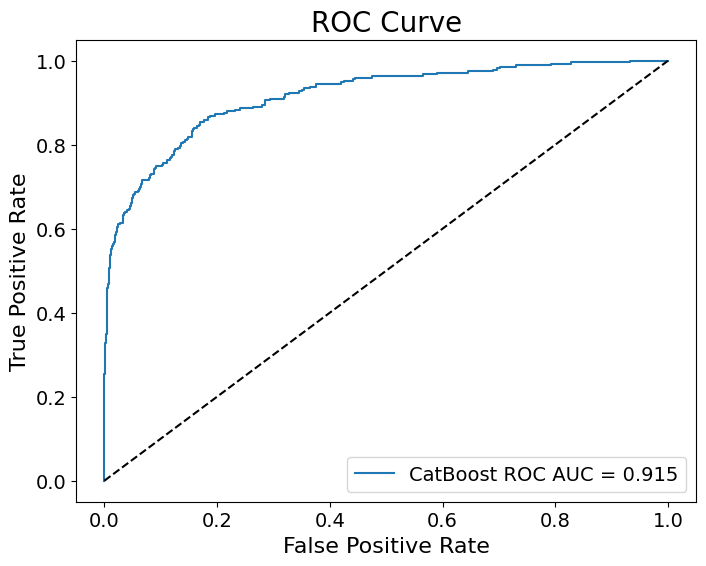

In [26]:
# Оценка лучшей модели на тестовой выборке
y_pred_proba = best_catboost_model.predict_proba(X_test)[:, 1]
y_pred = best_catboost_model.predict(X_test)

# Рассчитываем метрики
roc_auc_test = roc_auc_score(y_test, y_pred_proba)
accuracy_test = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"\n--- Оценка лучшей модели ({best_model_name}) на тестовой выборке ---")
print(f"ROC-AUC: {roc_auc_test:.4f}")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Проверка условия ROC-AUC >= 0.85
if roc_auc_test >= 0.85:
    print("\nУсловие ROC-AUC >= 0.85 выполнено!")
else:
    print("\nУсловие ROC-AUC >= 0.85 НЕ выполнено!")

# ROC-кривая для лучшей модели
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test.values, y_pred_proba)
plt.plot(fpr, tpr, label=f'{best_model_name} ROC AUC = {roc_auc_test:.3f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

CatBoost справился с заданием: значение метрики значительно лучше требуемой. Однако, значение Recall низкое.

## Матрица ошибок

Пострим матрицу ошибок лучшей модели.

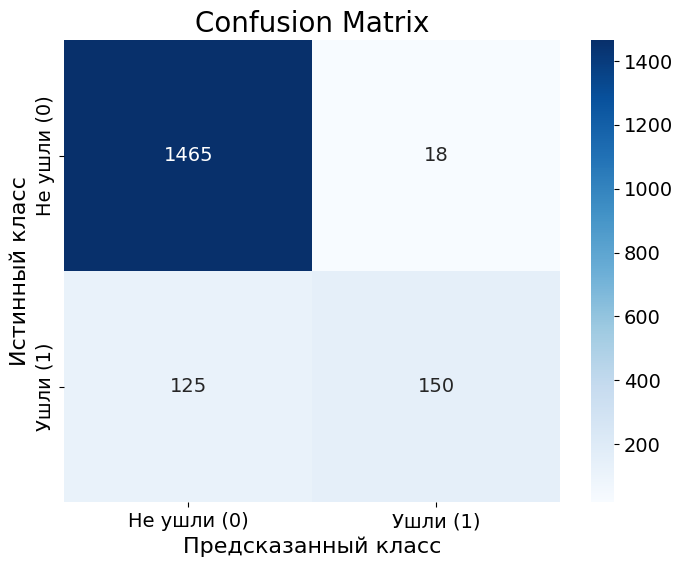

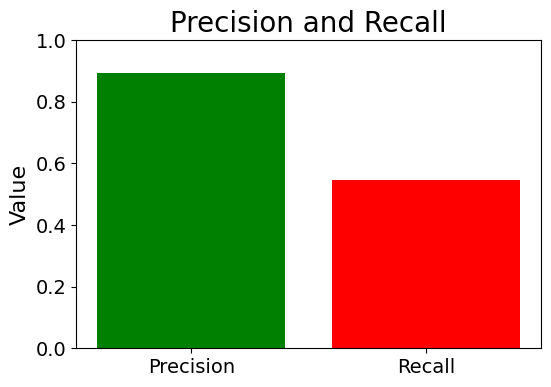

In [27]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Не ушли (0)', 'Ушли (1)'], 
           yticklabels=['Не ушли (0)', 'Ушли (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')

# График Precision и Recall
metrics = ['Precision', 'Recall']
values = [precision, recall]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values, color=['green', 'red'])
plt.title('Precision and Recall')
plt.ylabel('Value')
plt.ylim(0, 1)  # Устанавливаем лимит для оси Y от 0 до 1

plt.show()

### Промежуточный вывод:

Матрица ошибок показывает, что модель хорошо определяет клиентов, которые готовы остаться у провайдера. Однако, модель плохо улавливает клиентов, которые готовы уйти. Это связано, в первую очередь, с малым количеством "положительных" результатов в выборке, модель не успевает обучиться искать их. **Если клиенту критично найти как можно больше потенциально готовых уйти клиентов, то можно отрегулировать порог предсказания в сторону уменьшения.**

### Промежуточный вывод:

После применения оптимального порога метрика ROC-AUC всё ещё выше необходимой. Но уходящие клиенты предсказаны гораздо точнее.

## Анализ важности признаков

Оценим важность признаков для лучшей модели и построим графики важности с помощью библиотеки SHAP.

/opt/conda/lib/python3.9/site-packages/catboost/core.py:1171: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  self._init_pool(data, label, cat_features, text_features, embedding_features, pairs, weight, group_id, group_weight, subgroup_id, pairs_weight, baseline, timestamp, feature_names, thread_count)


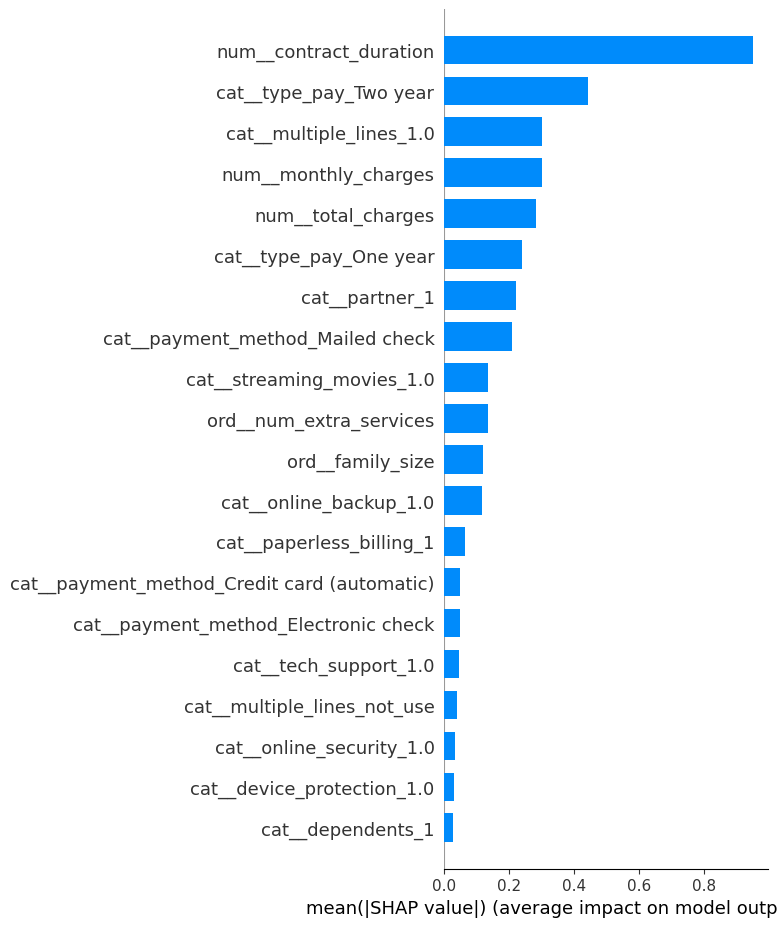

<Figure size 640x480 with 0 Axes>

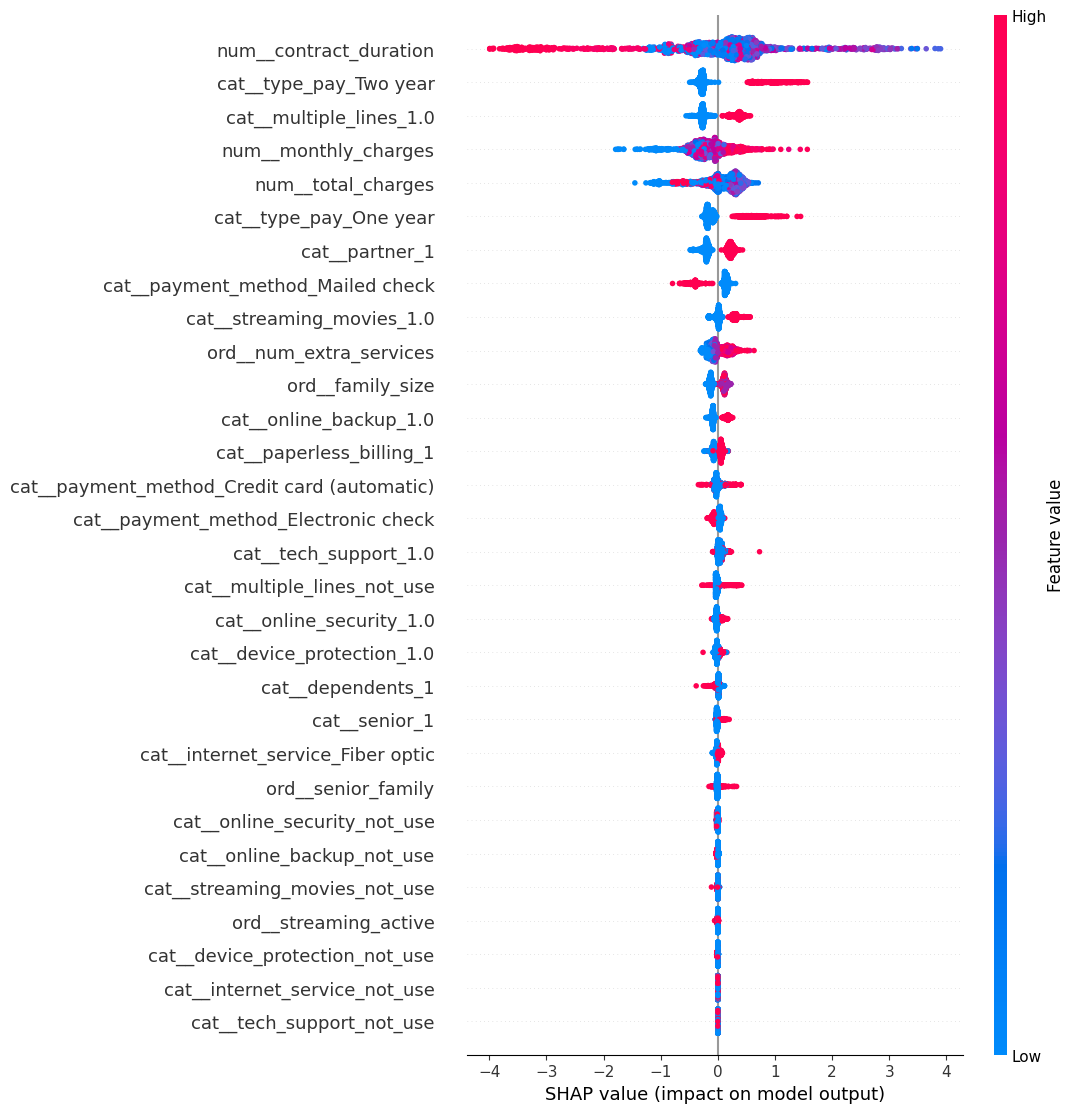

<Figure size 640x480 with 0 Axes>

In [28]:
# SHAP Analysis
feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test, columns=feature_names) 

explainer = shap.TreeExplainer(best_catboost_model)
shap_values = explainer(X_test_df) 

# Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type="bar")
plt.tight_layout()

# Beeswarm Plot
plt.figure()
shap.plots.beeswarm(shap_values, max_display=30)
plt.tight_layout()
plt.show()

### Промежуточный вывод:

Анализ важности признаков показал следующее:

* `contract_duration` - основной признак. На него модель опирается сильнее всего. Поэтому заказчику рекомендуется уделять внимание новым клиентам. Возможно, предлагать вторичные стимулирующие акции.
* `type_pay` - необходимо пересмотреть политику оплат. Много клиентов ушло по причине длительных двухгодичных контрактов: немногие готовы платить такие суммы на долгосрочную переспективу.
* `total_charges` - необходимо обратить внимание на группу тех, сумма трат которых мала (т.е. новые клиенты). Также нельзя забывать и про "старожилов" с наибольшими тратами.
* `monthly_charges` - логичный признак ежемесячных затрат клиентов. Если клиент тратит слишком много для своего бюджета, он постарается найти лучшие условия. Заказчику рекомендуется пересмотреть тарифную политику или заинтересовать клиентов на минимальных тарифах новыми дополнительными опциями, дать им попробовать бесплатный пробный период.
* `multiple_lines` - необходимо обратить внимание на качество этой услуги. Много клиентов, которые использовали эту услугу, ушло.

Для одного из важных входных признаков (`contract_duration`) проведём дополнительное исследование - покажем график зависимости входного и целевого признаков.

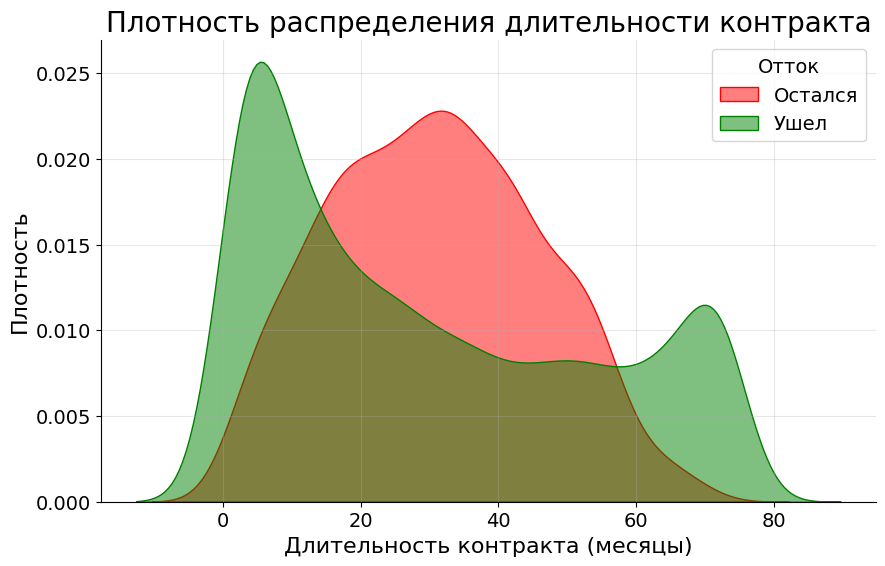

In [29]:
# Анализ зависимости 'contract_duration' и 'target'
# KDE plot для визуализации зависимости
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=final_df, x='contract_duration', hue='target',
    palette=['green', 'red'], fill=True, alpha=0.5,
    common_norm=False
)
plt.title('Плотность распределения длительности контракта')
plt.xlabel('Длительность контракта (месяцы)')
plt.ylabel('Плотность')
plt.legend(title='Отток', labels=['Остался', 'Ушел'])
plt.grid(alpha=0.3)
sns.despine() 
plt.show()

### Промежуточный вывод:

Как видно по графику, критически важно работать с группой первого года - абсолютное "первенство" по уходам за этой группой клиентов. Наиболее лояльны клиенты на горизонте использования услуг провайдера в 3-5 лет: здесь больше всего оставшихся и меньше всего ушедших. Но не стоит забывать и о группе пользователей-долгожителей: заметно, что в этой области идёт рост доли ушедших. Необходимо проработать взаимодействие и с этой группой.

## Общий вывод:

**Описание проекта "Телеком":**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. 

**Задача проекта** — обучить модель для прогноза оттока клиентов.

**Описание услуг**

Оператор предоставляет два основных типа услуг:

* Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
* Интернет. Подключение бывает двух типов: через телефонную линию DSL (англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (англ. fiber optic).

Также абонентам доступен ряд услуг:

* Интернет-безопасность: антивирус (Device Protection) и блокировка опасных сайтов (Online Security);
* Выделенная линия технической поддержки (Tech Support);
* Облачное хранилище файлов для резервного копирования данных (Online Backup);
* Стриминговое телевидение (Streaming TV) и каталог фильмов (Streaming Movies).

За услуги клиенты могут платить ежемесячно или раз в 1–2 года. Доступны различные способы расчёта и возможность получить электронный чек.

**В ходе предобработки данных** были отформатированы датасеты, построены графики, объяснены характеры распределения данных  и их аномалии.

В ходе объединения данных появились пропуски. Это объясняется тем, что не все пользователи используют интернет и не все используют телефонную связь (подключение телефона к нескольким линиям одновременно не используется в виду отсутствия собственно телефона). Чтобы не допустить смешивания различных абонентов, заполнили пропуски заглушкой `not_use`.

Также добавили синтетические признаки.

**В ходе исследовательского анализа** построены рафики зависимости целевого признака от различных параметров. Также были исключены параметры, не нужные в дальнейшей работе.

**С помощью матрицы корреляции `phik_matrix()`** показали, что утечки целевого параметра нет. 

Мультиколлинеарные признаки (корреляция >0.9):

* `monthly_charges` умеренно коррелирует с несколькими признаками, связанными с дополнительными услугами. 
Также сами доп. услуги коррелируют друг с другом. Скорее всего, это связано с заглушкой `not_use`.

**Подготовили данные для обучения:** разбили на обучающую и тестовую выборки с учётом стратификации целевого признака, с помощью трансформеров `OrdinalEncoder`, `OneHotEncoder` и `StandardScaler` преобразовали признаки. 

**Обучили несколько моделей:** Dummy, RandomForest, CatBoost, нейронную сеть. Подобрали гиперпараметры для моделей.

--- Сводка по производительности моделей ---
            Model   ROC-AUC
0           Dummy  0.504333
1  Neural Network  0.820387
2    RandomForest  0.813815
3        CatBoost  0.876102

Лучше всего с валидацией справилась модель CatBoost.

**Проверили качество лучшей модели на тестовой выборке.** 

--- Оценка лучшей модели (CatBoost) на тестовой выборке ---
ROC-AUC: 0.9138
Accuracy: 0.9130
Precision: 0.8547
Recall: 0.5345

Условие ROC-AUC >= 0.85 выполнено!

CatBoost справился с заданием: значение метрики значительно лучше требуемой. Однако, значение Recall низкое.

**Матрица ошибок** показала, что модель хорошо определяет клиентов, которые готовы остаться у провайдера. Однако, модель плохо улавливает клиентов, которые готовый уйти. Это связано, в первую очередь, с малым количеством "положительных" результатов в выборке, модель не успевает обучиться искать их. **Если клиенту критично найти как можно больше потенциально готовых уйти клиентов, то можно отрегулировать порог предсказания в сторону уменьшения.**

**Анализ важности признаков** провели с помощью библиотеки SHAP. 

Анализ важности признаков показал следующее:

* `contract_duration` - основной признак. На него модель опирается сильнее всего. Поэтому заказчику рекомендуется уделять внимание новым клиентам. Возможно, предлагать вторичные стимулирующие акции.
* `type_pay` - необходимо пересмотреть политику оплат. Много клиентов ушло по причине длительных двухгодичных контрактов: немногие готовы платить такие суммы на долгосрочную переспективу.
* `total_charges` - необходимо обратить внимание на группу тех, сумма трат которых мала (т.е. новые клиенты). Также нельзя забывать и про "старожилов" с наибольшими тратами.
* `monthly_charges` - логичный признак ежемесячных затрат клиентов. Если клиент тратит слишком много для своего бюджета, он постарается найти лучшие условия. Заказчику рекомендуется пересмотреть тарифную политику или заинтересовать клиентов на минимальных тарифах новыми дополнительными опциями, дать им попробовать бесплатный пробный период.
* `multiple_lines` - необходимо обратить внимание на качество этой услуги. Много клиентов, которые использовали эту услугу, ушло.

Для одного из важных входных признаков (`contract_duration`) провели дополнительное исследование - показали график зависимости входного и целевого признаков.

*Как видно по графику, критически важно работать с группой первого года - абсолютное "первенство" по уходам за этой группой клиентов. Наиболее лояльны клиенты на горизонте использования услуг провайдера в 3-5 лет: здесь больше всего оставшихся и меньше всего ушедших. Но не стоит забывать и о группе пользователей-долгожителей: заметно, что в этой области идёт рост доли ушедших. Необходимо проработать взаимодействие и с этой группой.*